# Session 5 Data Analytics: Data exploration and preparation

In this session, we will dive into data exploration and preparation in Python. To do so, we will again use the NPC case to demonstrate the code. In the last session, we read in the **subscription** and **customers** table and saved them as `parquet` files. Let's read them in first.

In [1]:
#ONLY FOR GOOGLE COLAB

# Code to access drive
from google.colab import drive
drive.mount('/content/drive')

# Set working directory to proper location
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/Data Analytics/Session 5")

Mounted at /content/drive


In [2]:
# Read the parquet files
import pandas as pd

# Load the subscriptions and customers datasets
subscriptions = pd.read_parquet('./Data/subscriptions.parquet')
customers = pd.read_parquet('./Data/customers.parquet')

## Data exploration

We will do some basic data exploration of the subscriptions table. We will therefore focus on the core set of data visualization tools: bar charts, lines charts, scatter plots, histograms and box plots.

In Python, the go-to package for data visualization is `matplotlib`. It provides a flexible framework for creating visualizations.

Recall that the **basic ideas** from `matplotlib` are:
- Figure: The overall container (e.g., window or canvas) for the plot.
- Axes: The plotting area within the figure, where data is visualized.
- Artists: Everything you see in the plot (lines, text, patches, etc.) is an artist.

The **usage** of a figure follows a structure workflow:
1. Import: `import matplotlib.pyplot as plt`
2. Create an empty figure: `fig = plt.figure()`
3. Create figure and axes: `fig, ax = plt.subplots()`
4. Plot data: `ax.plot(x, y)`
5. Display the plot: `plt.show()`

Before diving into the core chart types, it's worth seeing *why* visualization matters in the first place. **Anscombe's Quartet** (Anscombe, 1973) is a classic illustration: four small datasets that share the same mean, variance, and correlation for `x` and `y`, yet look completely different when plotted. `.describe()` can't tell these apart — a scatter plot immediately reveals the differences.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

anscombe = pd.DataFrame({
    'dataset': ['I'] * 11 + ['II'] * 11 + ['III'] * 11 + ['IV'] * 11,
    'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5] * 3
         + [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
    'y': [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68,
          9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74,
          7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73,
          6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
})

# Check whether the four datasets really do share the same summary statistics
summary = anscombe.groupby('dataset').agg(
    mean_x=('x', 'mean'), mean_y=('y', 'mean'),
    std_x=('x', 'std'), std_y=('y', 'std'),
    corr=('x', lambda s: s.corr(anscombe.loc[s.index, 'y'])),
)
summary.round(2)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, (name, group) in zip(axes.flat, anscombe.groupby('dataset')):
    ax.scatter(group['x'], group['y'], color='#2f6faa')
    coeffs = np.polyfit(group['x'], group['y'], 1)
    x_line = np.linspace(group['x'].min(), group['x'].max(), 50)
    ax.plot(x_line, np.polyval(coeffs, x_line), color='#c9772e', linewidth=1.5)
    ax.set_title(f'Dataset {name}')

fig.suptitle("Anscombe's Quartet: identical statistics, very different data", fontsize=13)
plt.tight_layout()
plt.show()

The image  below summarizes the strucutre of a figure in `matplotlib` and all the different elements that can be customized.

![anatomy](https://matplotlib.org/stable/_images/anatomy.png)

Some important elements:
- Title: Added using `ax.set_title()`.
- Axes: Created with `fig.subplots()`.
- Grid: Enabled using `ax.grid()`.
- Legend: Added using `ax.legend()`.
- Ticks and labels: Customized using `ax.set_xticks()`, `ax.set_yticks()`, `ax.set_xlabel()`, and `ax.set_ylabel()`.

This modular approach allows for precise control over every aspect of the visualization, making matplotlib a versatile tool for data exploration.

A short example of simple scatter plot can be found below:

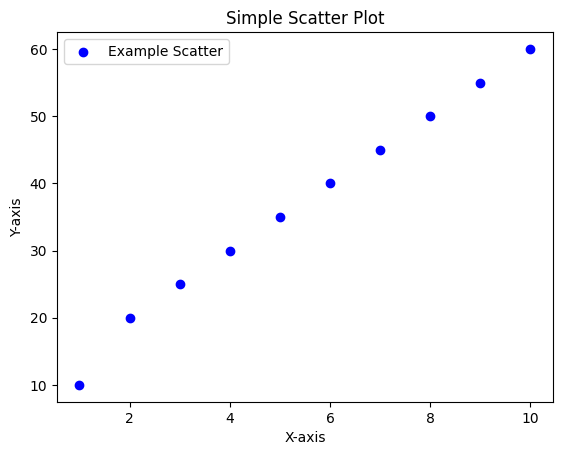

In [5]:
# Import
import matplotlib.pyplot as plt

# Sample data
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [10, 20, 25, 30, 35, 40, 45, 50, 55, 60]

# Create a figure and axes
fig, ax = plt.subplots()

# Plot the data as a scatter plot
ax.scatter(x, y, label='Example Scatter', color='blue', marker='o')

# Add title, labels, and legend
ax.set_title('Simple Scatter Plot')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()

# Display the plot
plt.show()

Let's now have a look how we can use the core set of charts on the subscriptions table. First, let's have a look at the data again:



In [ ]:
#Include all columns
subscriptions.describe(include='all')

,SubscriptionID,CustomerID,ProductID,Pattern,StartDate,EndDate,NbrNewspapers,NbrStart,RenewalDate,PaymentType,...,PaymentDate,FormulaID,GrossFormulaPrice,NetFormulaPrice,NetNewspaperPrice,ProductDiscount,FormulaDiscount,TotalDiscount,TotalPrice,TotalCredit
count,8252,8252,8252,8252,8252,8252,8252.0,8231.0,6232,8252,...,7831,8252,8091.000000,8091.000000,8091.000000,8091.000000,8091.000000,8091.000000,8091.000000,8091.000000
unique,8252,1389,8,11,NaN,NaN,<NA>,<NA>,NaN,2,...,NaN,621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1000687,663946,8,1111110,NaN,NaN,<NA>,<NA>,NaN,BT,...,NaN,924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,50,4383,8147,NaN,NaN,<NA>,<NA>,NaN,6743,...,NaN,425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2008-09-09 01:25:30.392632320,2009-03-11 22:57:52.612699904,159.824285,14.995748,2009-06-08 11:29:16.097561088,NaN,...,2008-08-17 02:57:37.949176320,NaN,135.877842,133.336547,0.856182,2.459114,2.541296,5.000410,125.372010,-0.529440
min,NaN,NaN,NaN,NaN,2006-01-02 00:00:00,2007-01-02 00:00:00,2.0,0.0,2007-09-26 00:00:00,NaN,...,2005-12-14 00:00:00,NaN,0.169733,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-235.000100
25%,NaN,NaN,NaN,NaN,2007-09-30 00:00:00,2008-03-08 00:00:00,76.0,10.0,2008-09-01 00:00:00,NaN,...,2007-08-30 12:00:00,NaN,68.000000,68.000000,0.809211,0.000000,0.000000,0.000000,29.600000,0.000000
50%,NaN,NaN,NaN,NaN,2008-10-01 00:00:00,2009-03-17 12:00:00,77.0,10.0,2009-06-01 00:00:00,NaN,...,2008-09-15 00:00:00,NaN,79.000000,79.000000,0.878289,0.000000,0.000000,0.000000,79.000000,0.000000
75%,NaN,NaN,NaN,NaN,2009-09-11 00:00:00,2010-02-18 00:00:00,304.0,25.0,2010-03-22 00:00:00,NaN,...,2009-08-14 00:00:00,NaN,235.000000,235.000000,0.973684,0.000000,0.000000,0.000000,235.000000,0.000000
max,NaN,NaN,NaN,NaN,2011-02-24 00:00:00,2011-03-02 00:00:00,354.0,30.0,2011-02-02 00:00:00,NaN,...,2011-01-27 00:00:00,NaN,310.914306,276.000000,1.120000,267.000000,138.000000,267.000000,635.960000,0.000000


### Bar chart

A bar chart shows for each category a rectangular bars, where the length or height of each bar represents the value or frequency of that category.

Let's make a bar chart that counts the frequency of each `PaymentStatus`.

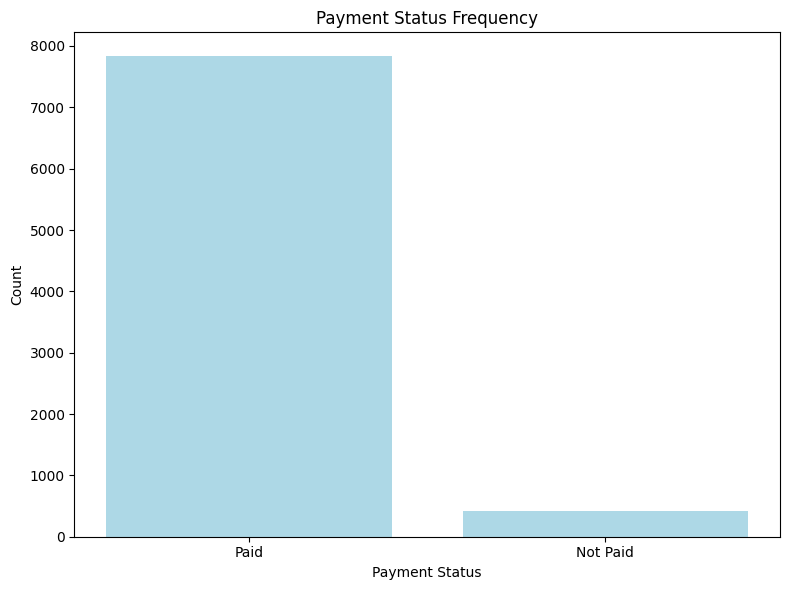

In [8]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Count occurrences of each payment status
payment_counts = subscriptions['PaymentStatus'].value_counts()
ax.bar(payment_counts.index, payment_counts.values, color='lightblue')

ax.set_title('Payment Status Frequency')
ax.set_xlabel('Payment Status')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

Let's brush this up a bit by making a horizontal bar chart and add the final frequency values on next to the bars

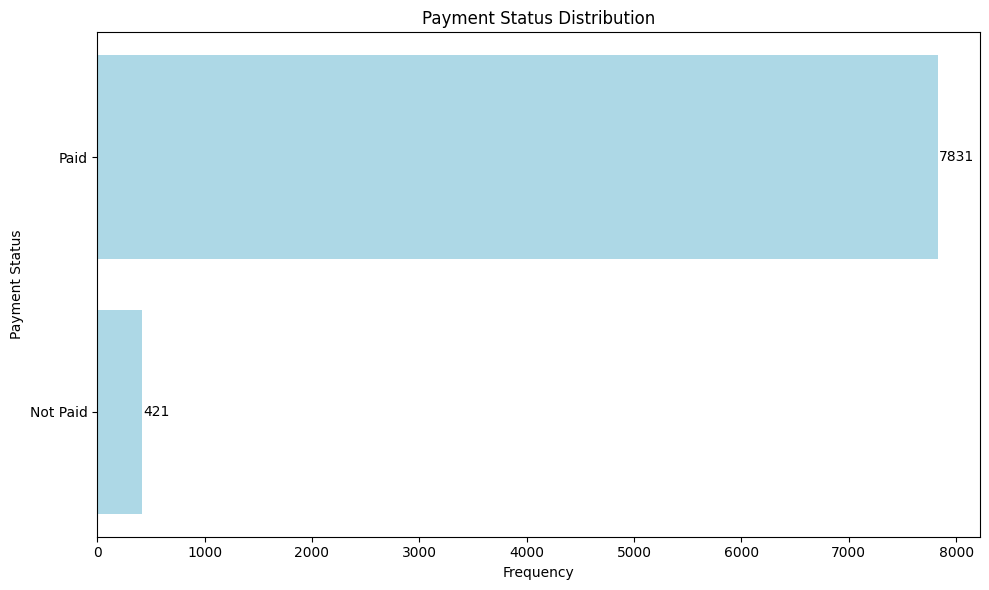

In [9]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Count occurrences of each payment status
payment_counts = subscriptions['PaymentStatus'].value_counts(ascending=True)

# Create horizontal bar chart
bars = ax.barh(payment_counts.index, payment_counts.values, color='lightblue')

# Add values on the bars
for i, (bar, value) in enumerate(zip(bars, payment_counts.values)): # Use enumerate for indexing and zip to iterate over bars and values
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(value), ha='left', va='center')

ax.set_title('Payment Status Distribution')
ax.set_xlabel('Frequency')
ax.set_ylabel('Payment Status')

plt.tight_layout()
plt.show()

A good alternative to a bar chart is a **lollipop** chart, which can be created by combining a line and scatter plot:

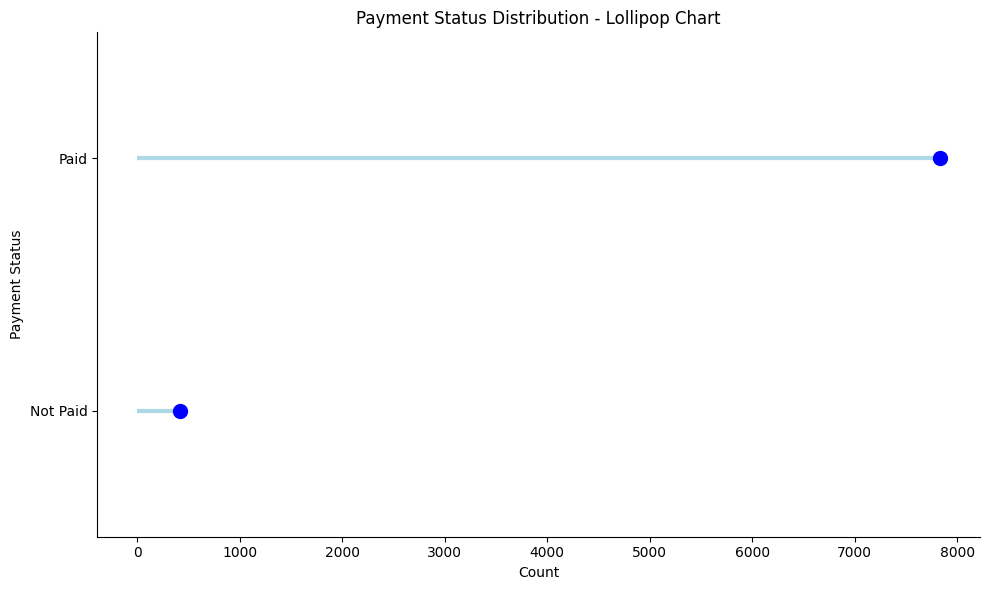

In [12]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create lollipop chart
ax.hlines(y=range(len(payment_counts)), xmin=0, xmax=payment_counts.values, color='lightblue', linewidth=3)
ax.scatter(payment_counts.values, range(len(payment_counts)), color='blue', s=100, zorder=3)

# Set y-axis labels
ax.set_yticks(range(len(payment_counts)))
ax.set_yticklabels(payment_counts.index)

# Adjust y-axis limits to reduce spacing
ax.set_ylim(-0.5, len(payment_counts) - 0.5)

ax.set_title('Payment Status Distribution - Lollipop Chart')
ax.set_xlabel('Count')
ax.set_ylabel('Payment Status')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Line chart

A line chart shows data points connected by lines to show trends or changes in behavior over time (or any ordered measurement). It’s ideal for visualizing continuous data across a sequence.

Let's make a line chart for the `TotalPrice`.

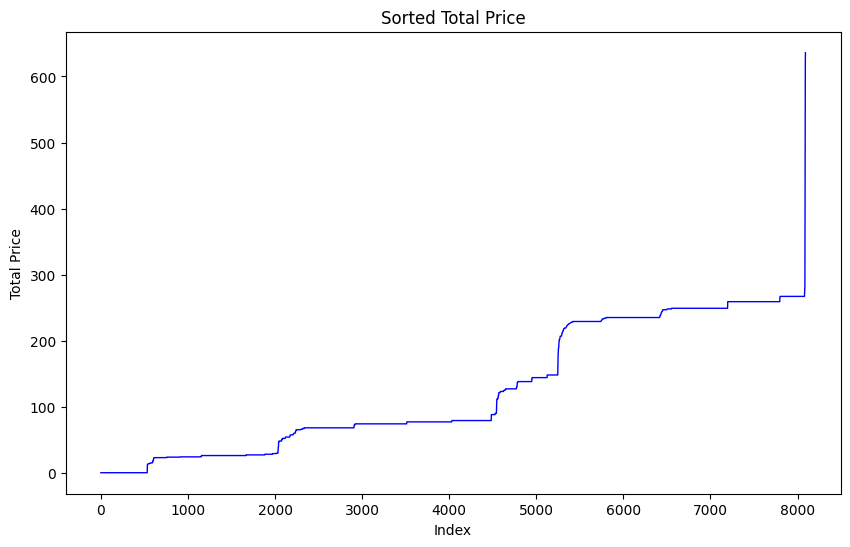

In [13]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

sorted_prices = np.sort(subscriptions['TotalPrice'].dropna())
ax.plot(range(len(sorted_prices)), sorted_prices, color='blue', linewidth=1)

ax.set_title('Sorted Total Price')
ax.set_xlabel('Index')
ax.set_ylabel('Total Price')

plt.show()

In this plot, the sorted `TotalPrice` values against their `index` positions (0, 1, 2, 3, ...).

This creates what's essentially a cumulative distribution or rank plot showing:
- X-axis: Index position (rank) of each subscription when sorted by price
- Y-axis: The actual price values in ascending order

This is useful for showing the distribution of prices and spot any outliers.

However, as you pointed out earlier, this isn't a true time series line chart. For a time-based line chart, you need to plot against actual dates like `StartDate` or `EndDate` to show how prices change over time. Let's therefore plot the average total price per month:

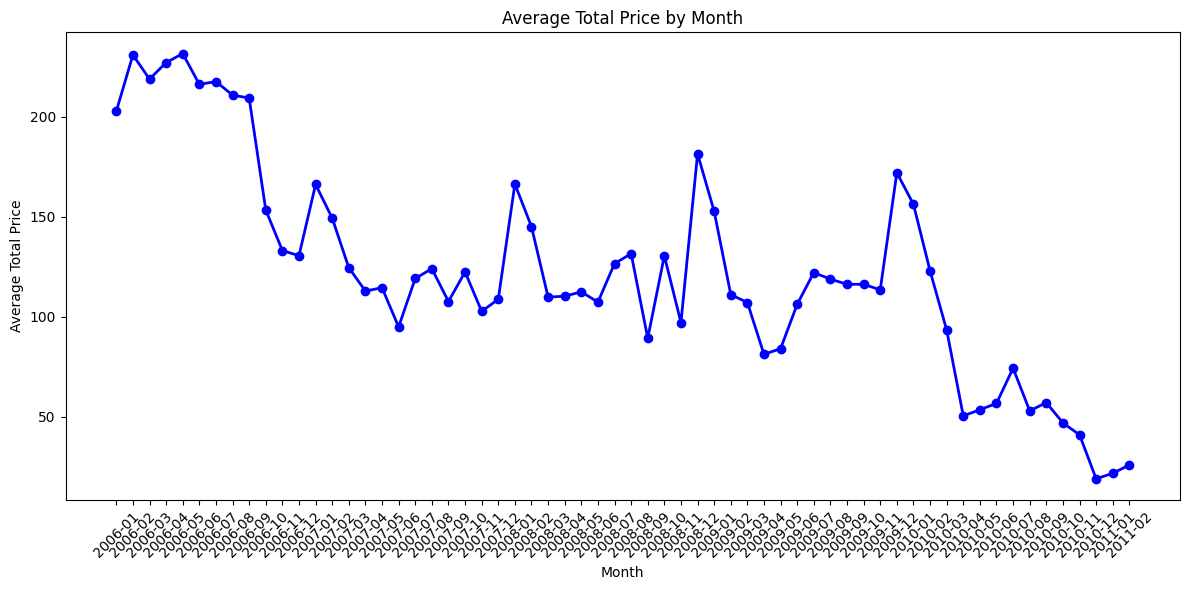

In [15]:
# Compute average TotalPrice per month
subscriptions_monthly = subscriptions.copy()
subscriptions_monthly['StartDate'] = pd.to_datetime(subscriptions_monthly['StartDate'])
subscriptions_monthly['YearMonth'] = subscriptions_monthly['StartDate'].dt.to_period('M')

monthly_avg = subscriptions_monthly.groupby('YearMonth')['TotalPrice'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_avg.index.astype(str), monthly_avg.values, color='blue', linewidth=2, marker='o')
ax.set_title('Average Total Price by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average Total Price')

plt.xticks(rotation=45) #for better readability
plt.tight_layout()
plt.show()

### Scatter plots

A scatter plot displays data points to show the relationship between two numerical variables. It’s ideal for identifying correlations, clusters, or outliers in data.

Let's first make simple scatter plot between the `NbrNewsPapers` and `TotalPrice`.

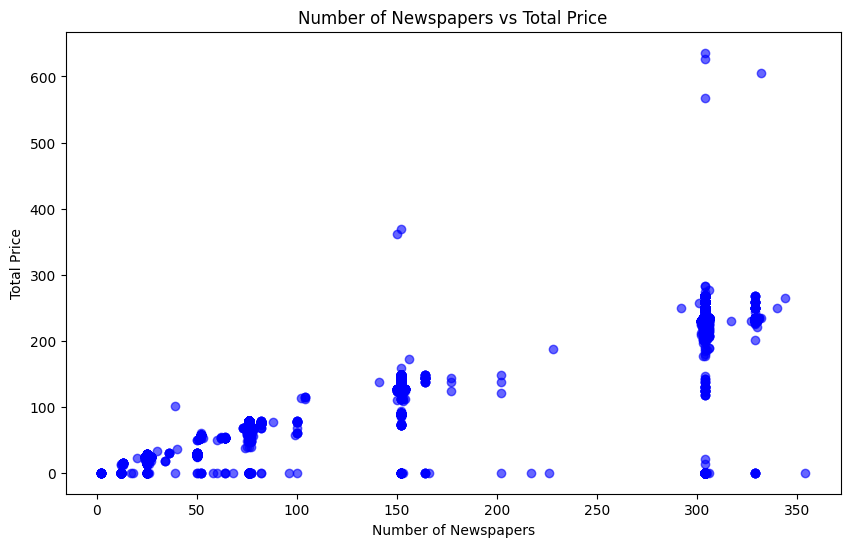

In [20]:
# Simple scatterplot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(subscriptions['NbrNewspapers'], subscriptions['TotalPrice'], alpha=0.6, color='blue')

ax.set_title('Number of Newspapers vs Total Price')
ax.set_xlabel('Number of Newspapers')
ax.set_ylabel('Total Price')

plt.show()

In a lot of cases it is interesting to add a regression line to the scatter plot to see the overall trend in the data. Doing this with `matplotlib` is quite extensive. A better way in that regard is to use `seaborn`. `Seaborn` is a high-level data visualization library built on top of `matplotlib`.  

It provides simpler syntax and prettier default styles, making it easy to create **statistical graphics** like regression plots, boxplots, heatmaps, and pair plots.  

Hence, compared to `matplotlib`it has the following advantages:
- More aesthetic by default (better color palettes and layouts)  
- More concise for complex plots  
- Better integrated with pandas DataFrames  
- Matplotlib offers more control and customization

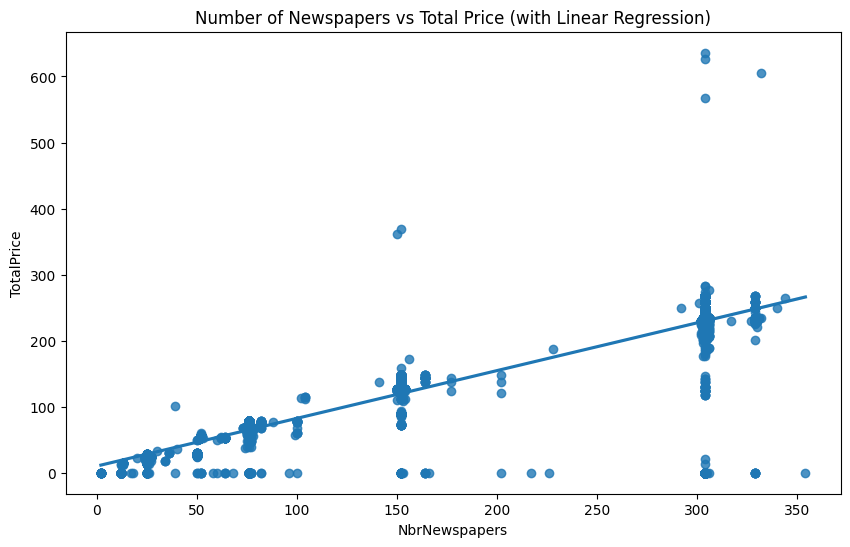

In [21]:
import seaborn as sns

# Simple regression plot with seaborn
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=subscriptions, x='NbrNewspapers', y='TotalPrice', ax=ax)
ax.set_title('Number of Newspapers vs Total Price (with Linear Regression)')
plt.show()

You can also add other more advanced lines like a **loess** (locally estimated scatterpot smoothing) curve, which is  nonparametric technique that fits local regressions around each data point to show nonlinear trends:

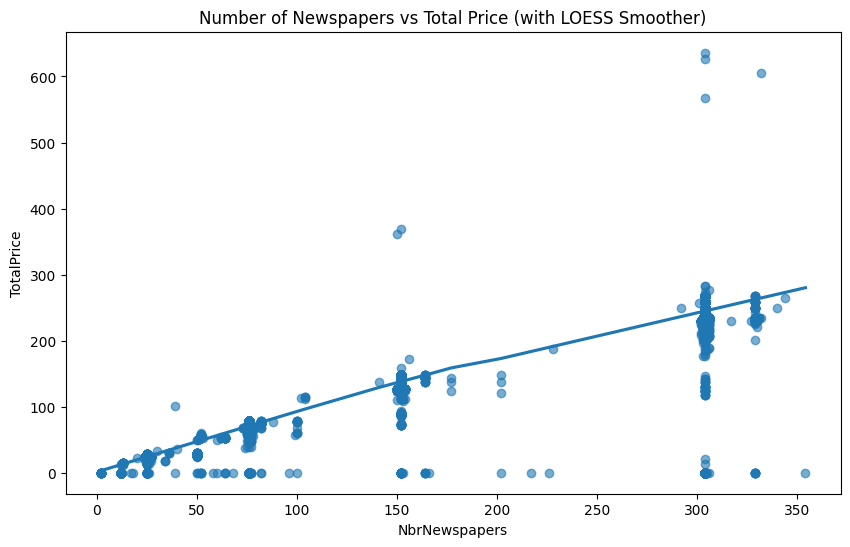

In [22]:
# Regression plot with LOESS or LOWESS smoother
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=subscriptions, x='NbrNewspapers', y='TotalPrice',
           lowess=True, scatter_kws={'alpha':0.6}, ax=ax)
ax.set_title('Number of Newspapers vs Total Price (with LOESS Smoother)')
plt.show()

In most cases, you are not interested in one scatter plot but in a pair plot that builds scatter plots for pairs the numeric variables. In `searborn` this can be done with just a few lines of line of code.

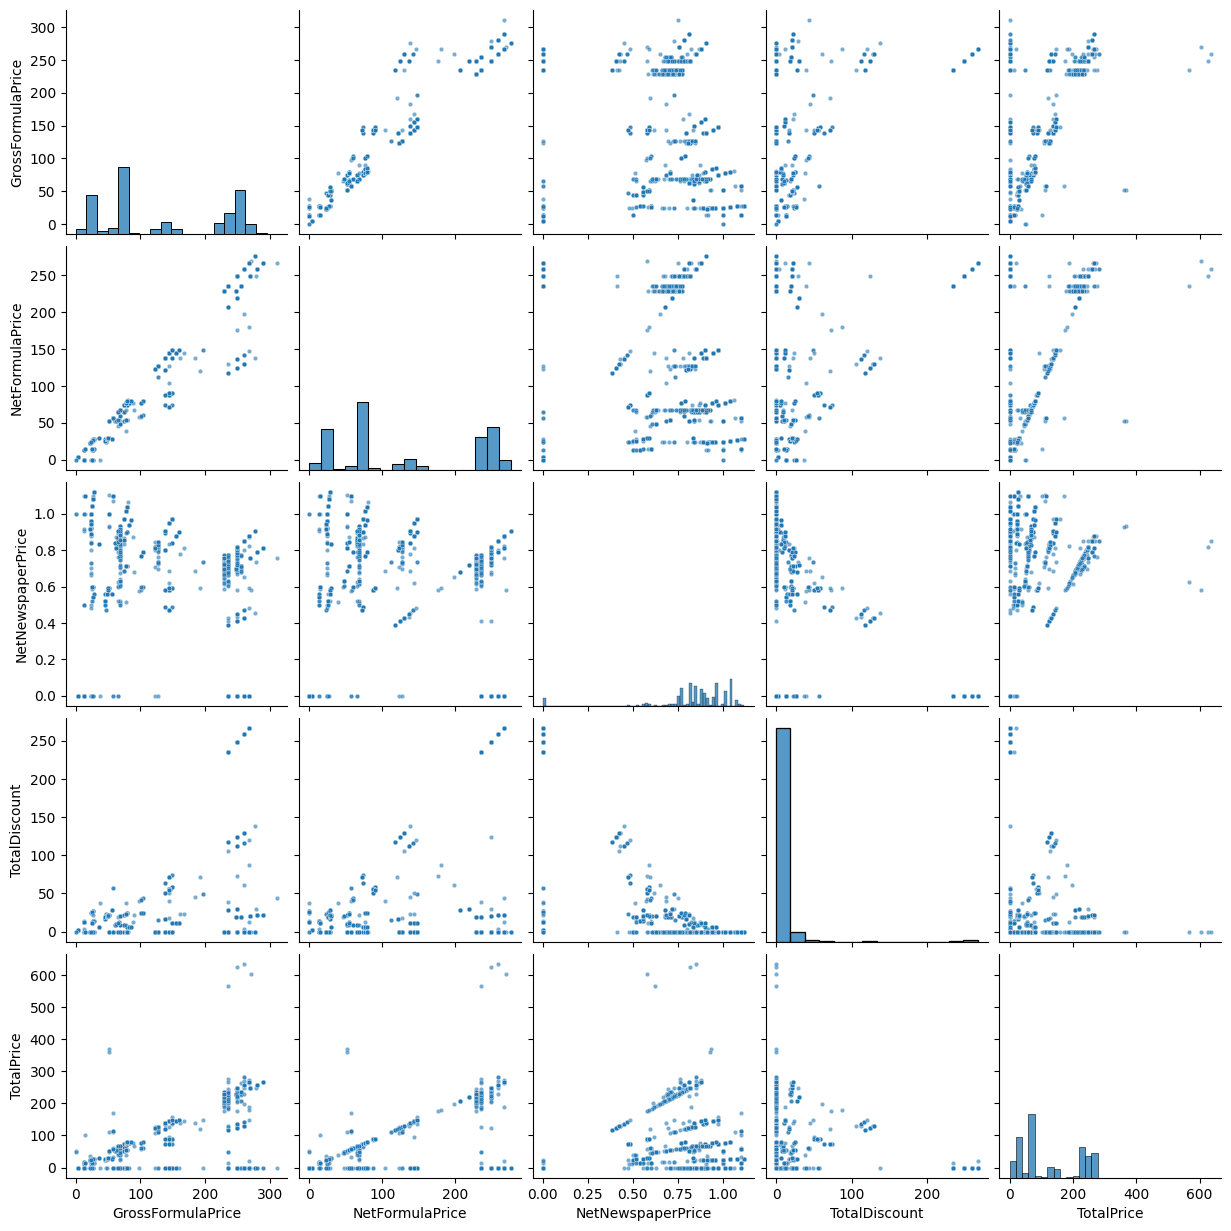

In [23]:
# Seaborn pairplot
numeric_cols = ['GrossFormulaPrice', 'NetFormulaPrice', 'NetNewspaperPrice', 'TotalDiscount', 'TotalPrice']
sns.pairplot(subscriptions[numeric_cols].dropna(), diag_kind='hist', plot_kws={'alpha':0.6, 's':10})
plt.show()

You can also do this for all numeric columns autmatically. Note that regression lines can also be added with `kind='reg'`.

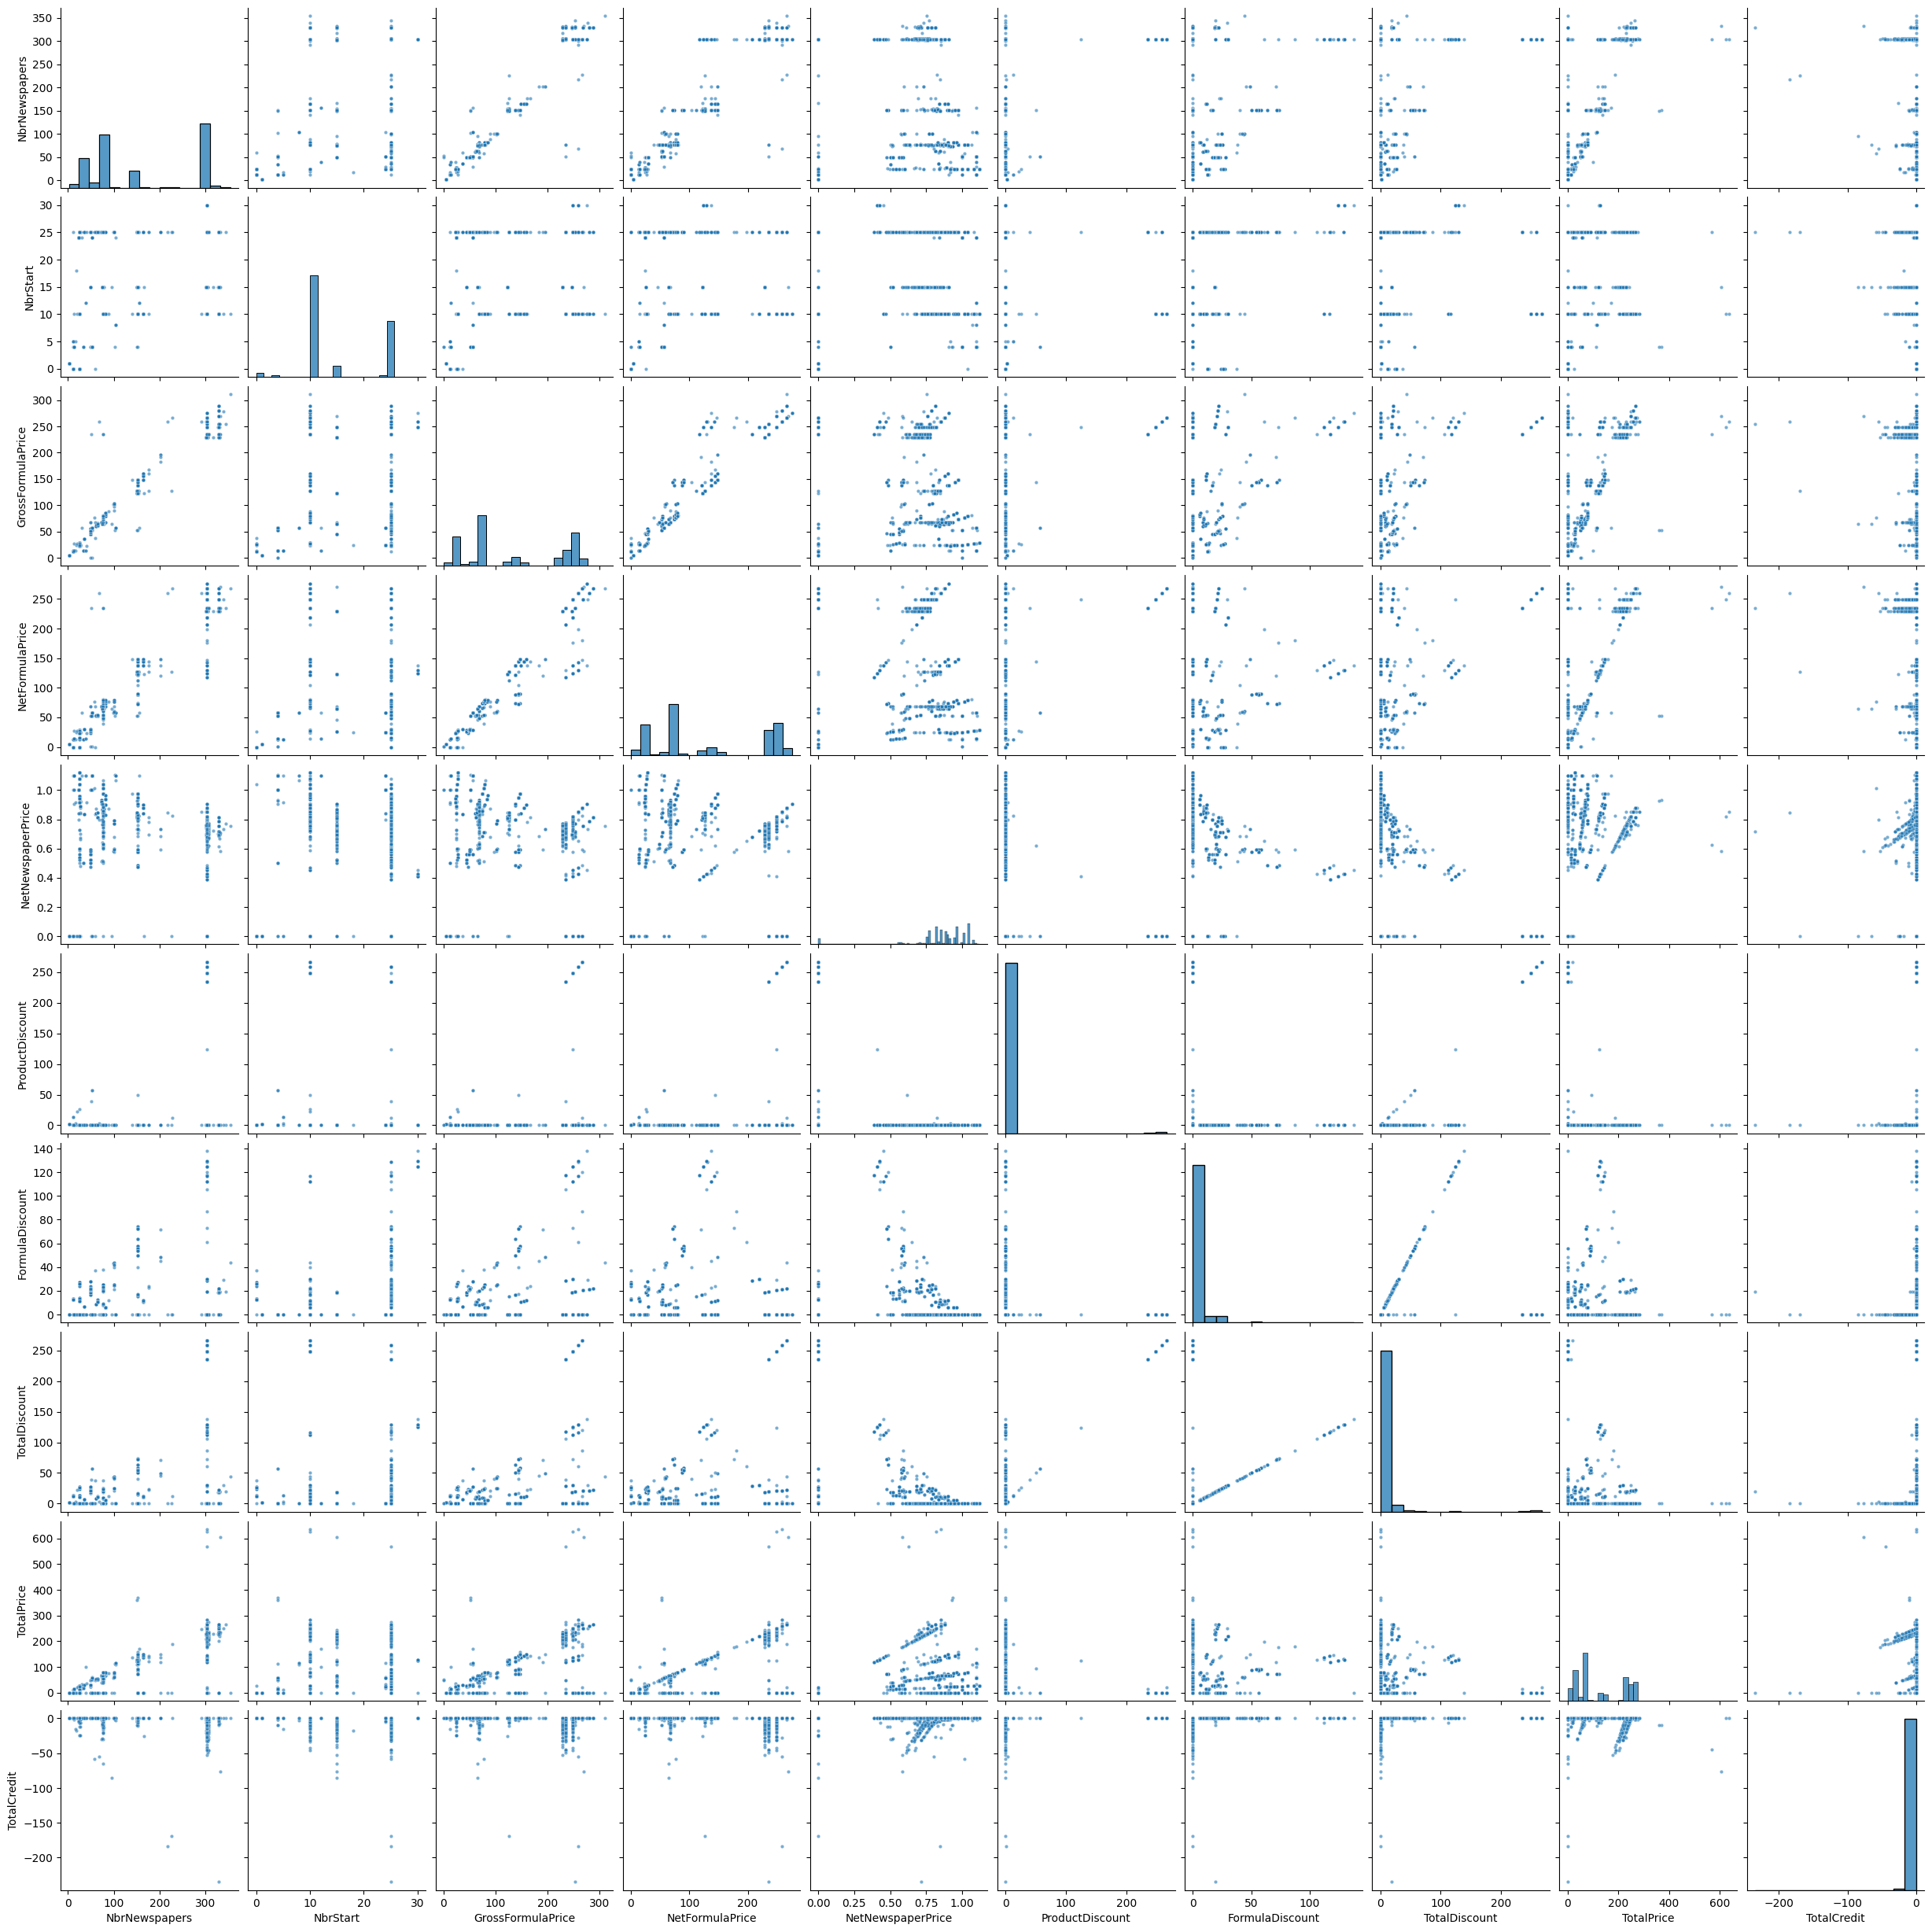

In [24]:
# Auto-select all numeric columns
sns.pairplot(subscriptions, diag_kind='hist', plot_kws={'alpha':0.6, 's':10})
plt.show()

### Histogram

A histogram shows the distribution of a variable by grouping data into bins and showing how many observations fall into each bin. It’s useful for visualizing the shape, spread, and skewness of the data.

Let's plot a histogram of the `TotalPrice`.

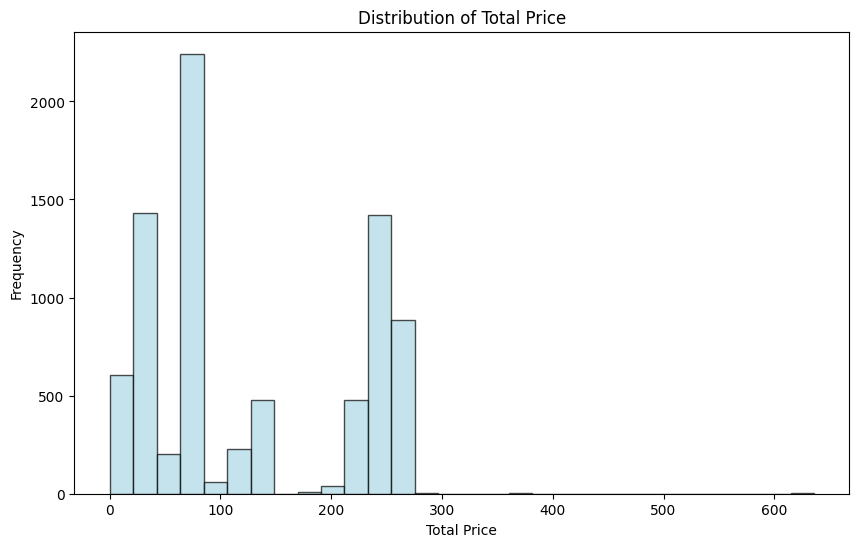

In [25]:
# Histogram of TotalPrice
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(subscriptions['TotalPrice'].dropna(), bins=30, color='lightblue', edgecolor='black', alpha=0.7)

ax.set_title('Distribution of Total Price')
ax.set_xlabel('Total Price')
ax.set_ylabel('Frequency')

plt.show()

If not specified, the bin width is automatically determined `bin width = (max(data) - min(data)) / number of bins`. However, you can also choose to make this more specific. For example, let's go for a bin width of 10.

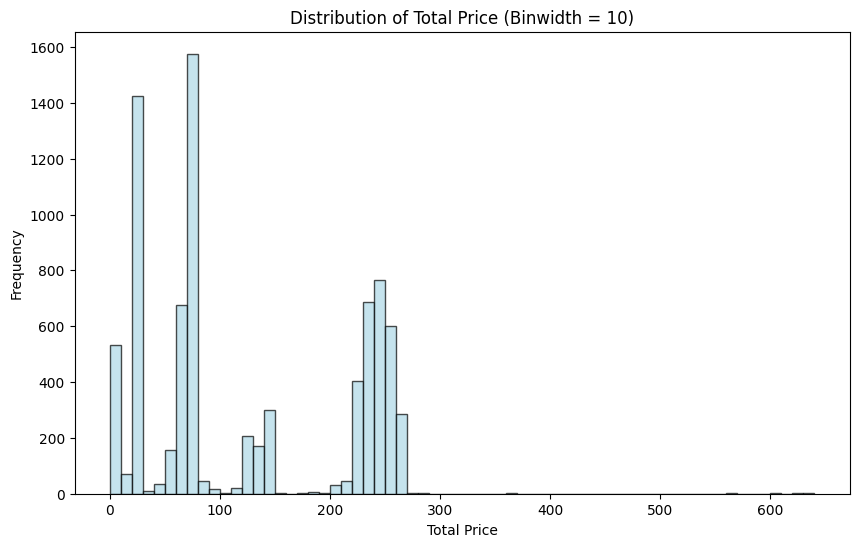

In [30]:
# Histogram with custom bin width
fig, ax = plt.subplots(figsize=(10, 6))

# Custom bin width of 10
min_price = subscriptions['TotalPrice'].min()
max_price = subscriptions['TotalPrice'].max()
bins = np.arange(min_price, max_price + 10, 10)  # binwidth = 10

ax.hist(subscriptions['TotalPrice'].dropna(), bins=bins, color='lightblue', edgecolor='black', alpha=0.7)

ax.set_title('Distribution of Total Price (Binwidth = 10)')
ax.set_xlabel('Total Price')
ax.set_ylabel('Frequency')

plt.show()

To get exactly 10 bins, you can specify the number of bins directly.

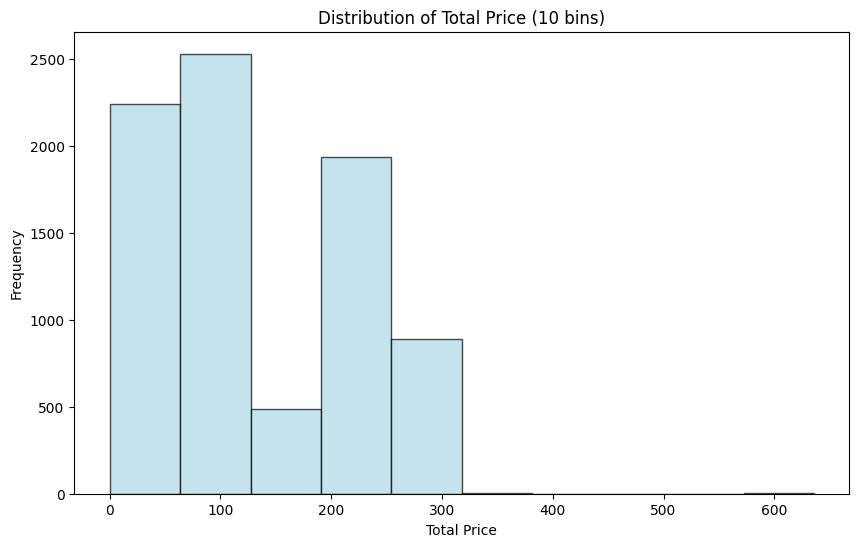

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(subscriptions['TotalPrice'].dropna(), bins=10, color='lightblue', edgecolor='black', alpha=0.7)
ax.set_title('Distribution of Total Price (10 bins)')
ax.set_xlabel('Total Price')
ax.set_ylabel('Frequency')
plt.show()

Again, you can also use `seaborn`, which has an overall nicer look and feel and you can specify the `binwidth` direclty.

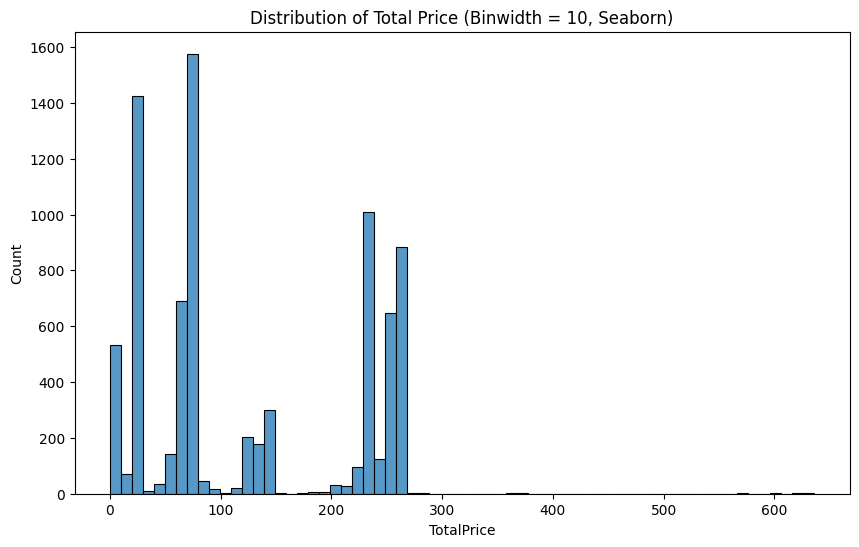

In [28]:
# Histogram with seaborn with binwidth of 10
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=subscriptions, x='TotalPrice', binwidth=10, ax=ax)
ax.set_title('Distribution of Total Price (Binwidth = 10, Seaborn)')
plt.show()

### Box plot

A box plot is a compact way to show the main statistics of a numerical variable, including the median, quartiles, and potential outliers. It’s especially useful for comparing distributions across groups.

Let's make a bit trickier and make a box plot for the `TotalPrice` per `PaymentType`. When you do this with `matplotlib` you should take into acount that the data should look like this:



In [ ]:
# DON'T RUN
data_for_boxplot = [
    [group1_value1, group1_value2, group1_value3, ...],  # All TotalPrice values for PaymentType 1
    [group2_value1, group2_value2, group2_value3, ...],  # All TotalPrice values for PaymentType 2
    [group3_value1, group3_value2, group3_value3, ...]   # All TotalPrice values for PaymentType 3
]

Let's now get the data in the proper format and then plot the box plot.

/tmp/ipython-input-1685976683.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_for_boxplot = [group['TotalPrice'].dropna().values for name, group in subscriptions.groupby('PaymentType')]
/tmp/ipython-input-1685976683.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(data_for_boxplot, labels=labels, patch_artist=True,


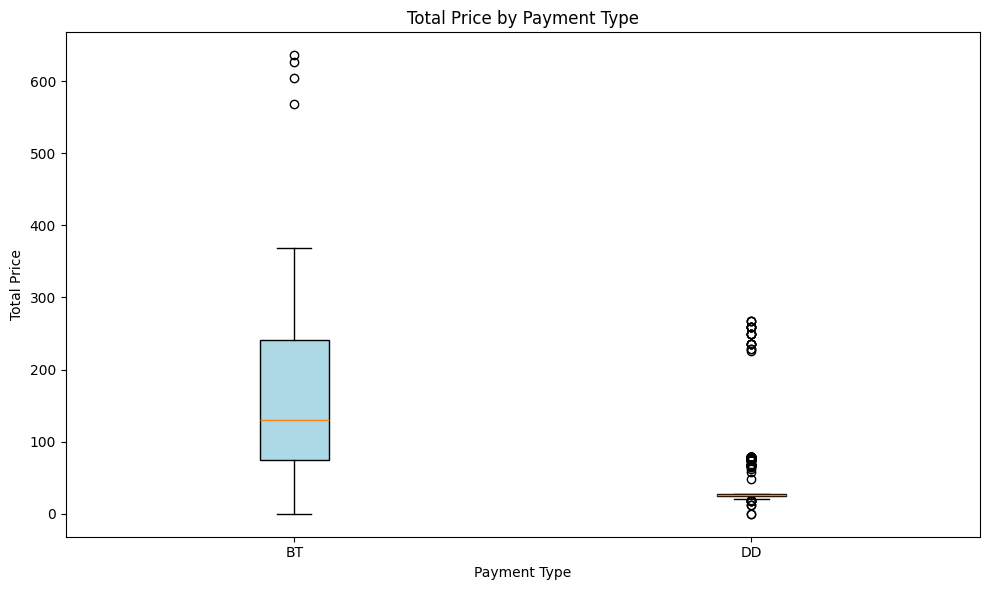

In [31]:
# Box plot of TotalPrice by PaymentType
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for boxplot
data_for_boxplot = [group['TotalPrice'].dropna().values for name, group in subscriptions.groupby('PaymentType')]
labels = subscriptions['PaymentType'].dropna().unique()

# Create boxplot
box_plot = ax.boxplot(data_for_boxplot, labels=labels, patch_artist=True,
                      boxprops=dict(facecolor='lightblue'))

ax.set_title('Total Price by Payment Type')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Total Price')

plt.tight_layout()
plt.show()


This code feels really verbose. Luckily `seaborn` makes this way more compact and does the grouping automatically.

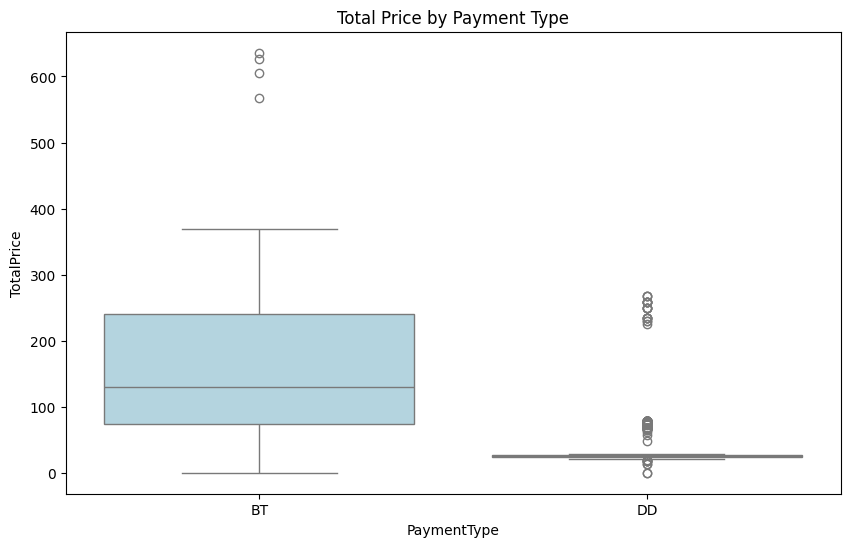

In [32]:
# No data preparation needed at all with seaborn
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=subscriptions, x='PaymentType', y='TotalPrice', color='lightblue', ax=ax)
ax.set_title('Total Price by Payment Type')
plt.show()

### Data quality

Now that you know how to make the basic charts in Python. We can have a look at the most common data quality issues. Remember that the most common data quality issues are:
- multicollinearity,
- missings values,
- and outliers.

We will show in this section how to detect and handle these issues.  

#### Multicollinearity

Multicollinearity occurs when independent variables in a dataset are highly correlated with each other. This can cause problems in statistical modeling as it makes it difficult to determine the individual effect of each variable.

Some basic correlation checking functions using `pandas` and `numpy`:

In [33]:
# To check correlation, focus only on numeric variables

# Select only numeric columns
numeric_cols = subscriptions.select_dtypes(include=[np.number])

# Calculate correlation matrix (automatically removes NaN values)
# Pearson correlation is used by default
correlation_matrix = numeric_cols.corr()

# Round the correlations for better readability when printed
print("\nRounded correlation matrix:")
print(correlation_matrix.round(2))


Rounded correlation matrix:
                   NbrNewspapers  NbrStart  GrossFormulaPrice  \
NbrNewspapers               1.00     -0.01               0.99   
NbrStart                   -0.01      1.00              -0.05   
GrossFormulaPrice           0.99     -0.05               1.00   
NetFormulaPrice             0.99     -0.07               0.99   
NetNewspaperPrice          -0.26     -0.09              -0.24   
ProductDiscount             0.12      0.00               0.12   
FormulaDiscount            -0.01      0.17              -0.00   
TotalDiscount               0.10      0.07               0.11   
TotalPrice                  0.90     -0.05               0.90   
TotalCredit                -0.08     -0.06              -0.07   

                   NetFormulaPrice  NetNewspaperPrice  ProductDiscount  \
NbrNewspapers                 0.99              -0.26             0.12   
NbrStart                     -0.07              -0.09             0.00   
GrossFormulaPrice             0.9

Researchers often create correlation plots to get a nice and quick overview of the correlations between variables. In Python, we can use `seaborn` and `matplotlib` to create correlation heatmaps.

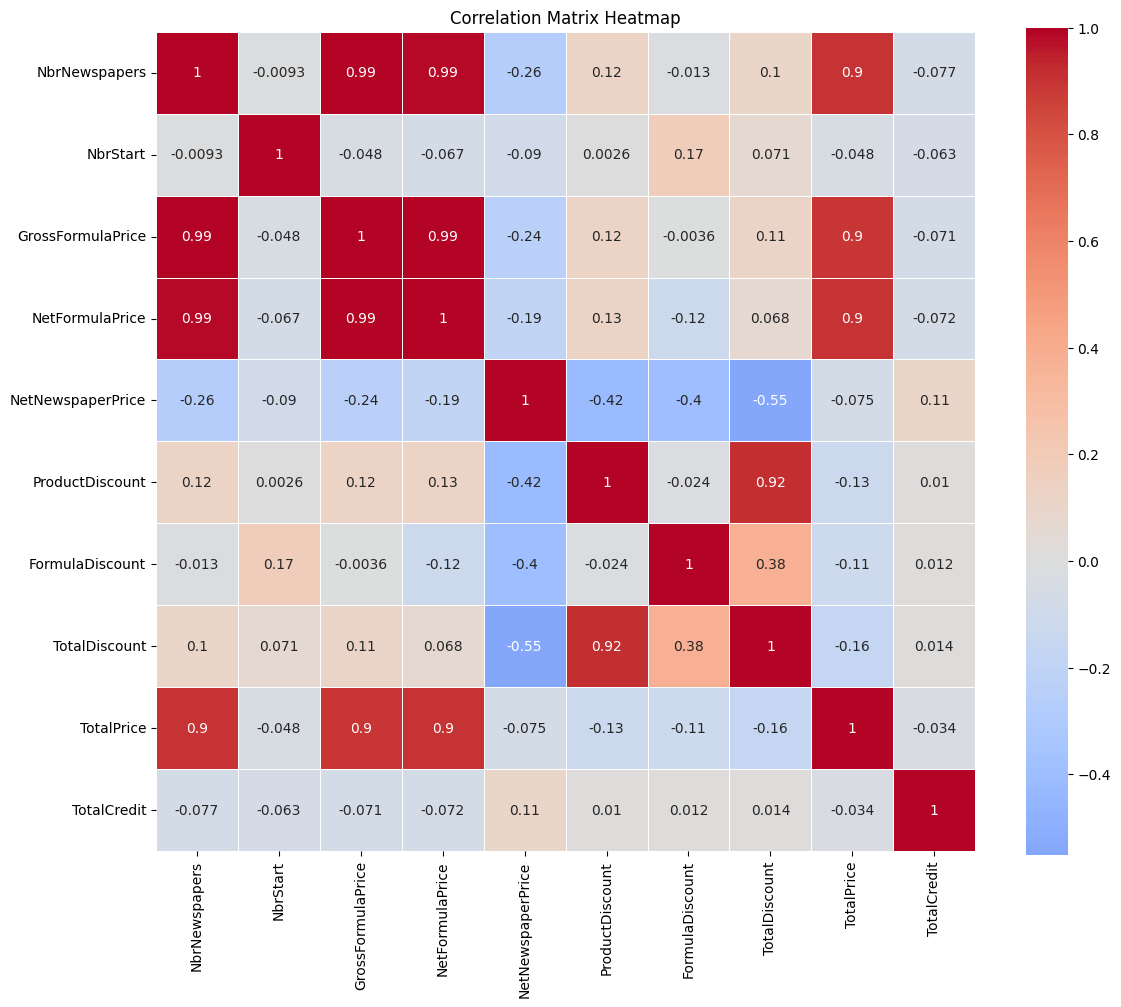

In [34]:
# Create correlation plot with circles/heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

A cluster map might be an even better alternative since it automatically re-orders rows and columns such that the most similar ones are clustered together. It also shows how the clusters of rows or columns are merged by adding a dendrogram on top.

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 1200x1000 with 0 Axes>

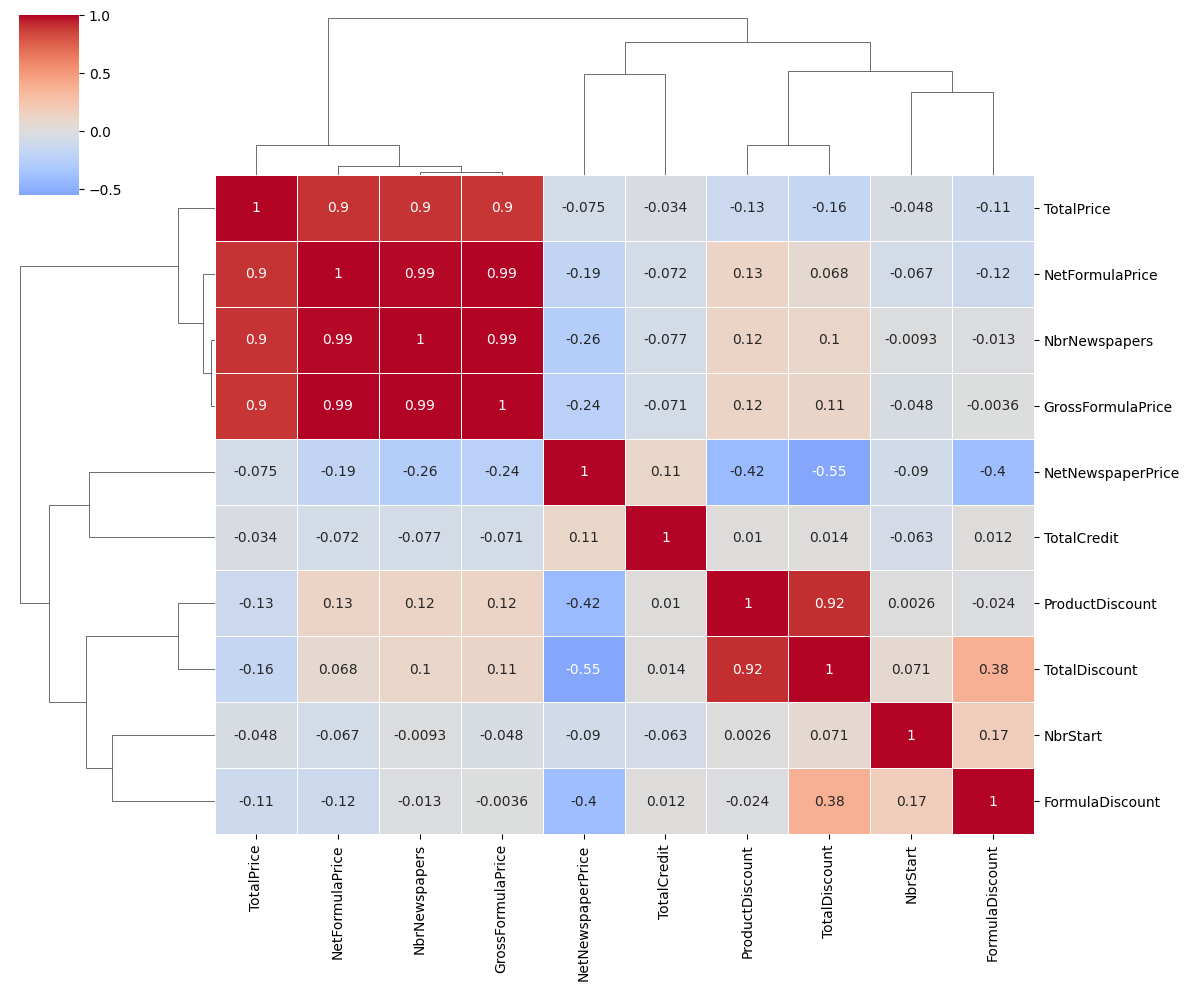

In [35]:
# Alternative: Create a clustermap for better visualization
plt.figure(figsize=(12, 10))
sns.clustermap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
               square=True, linewidths=0.5, figsize=(12, 10))
plt.show()

We saw earlier a **two heuristics** to delete highly correlated variables and solve multicollinearity.

- **Heuristic 1: the average correlation**: Determine the two highest correlated variables, delete the one with the highest average correlation with all other variables, and iterate until your correlation is below the desired threshold.
- **Heuristic 2: highest correlation pairs**: Identify correlated feature groups/pairs and remove features to ensure no remaining features have correlations above the threshold.

In Python, heuristic 2 is directly available through the **`feature-engine` library**, while heuristic 1 can easily be implemented ourselves (shown further below). The `DropCorrelatedFeatures` transformer automatically detects and removes highly correlated numerical variables to reduce redundancy in your dataset:
1. It computes the pairwise correlations between all numerical features using `pandas.corr()` (methods like Pearson, Spearman, or Kendall).
2.	For each pair of features exceeding a chosen correlation threshold, it keeps the first feature and drops the others, following a simple first found, first removed rule.
3.	Only numerical variables are evaluated; categorical or datetime features are automatically ignored unless specified otherwise.

In [37]:
%pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 18.8 MB/s eta 0:00:00


In [38]:
# Heurstic 2: correlation pairs
from feature_engine.selection import DropCorrelatedFeatures

# Initialize the transformer:
# - method: correlation method ('pearson', 'spearman', 'kendall')
# - threshold: correlation threshold (0.75 means correlations > 0.75 trigger removal)
# - variables: specify which variables to consider (None = all numeric)
dcf = DropCorrelatedFeatures(variables=None, method='pearson', threshold=0.75)

# Fit the transformer to identify correlated features
dcf.fit(numeric_cols.dropna())

# Get the features that would be dropped
features_to_drop = dcf.features_to_drop_

print(f"Features to remove: {features_to_drop}")
print(f"Number of features to remove: {len(features_to_drop)}")

print("\n" + "="*60 + "\n")

Features to remove: ['NbrNewspapers', 'NetFormulaPrice', 'TotalPrice', 'TotalDiscount']
Number of features to remove: 4




However, a more straightforward **simple correlation-based approach** could be to use `pandas` built-in functionality to identify any features that have correlations above the threshold with other features, and delete these ones.

In [39]:
# Simple correlation-based approach using pandas
def find_correlated_features(corr_matrix, threshold=0.75):
    """
    Find features that have correlations above threshold with any other features
    """
    # Get upper triangle of correlation matrix (avoid double counting)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column].abs() > threshold)]

    return to_drop

# Apply the simple method
corr_features_to_drop = find_correlated_features(correlation_matrix, threshold=0.75)

print(f"Features with high correlations: {corr_features_to_drop}")
print(f"Number of features identified: {len(corr_features_to_drop)}")

# Show the actual correlation matrix
print(f"\nCorrelation matrix for identified features:")
high_corr_subset = correlation_matrix.loc[corr_features_to_drop, corr_features_to_drop]
print(high_corr_subset.round(3))

Features with high correlations: ['GrossFormulaPrice', 'NetFormulaPrice', 'TotalDiscount', 'TotalPrice']
Number of features identified: 4

Correlation matrix for identified features:
                   GrossFormulaPrice  NetFormulaPrice  TotalDiscount  \
GrossFormulaPrice              1.000            0.993          0.113   
NetFormulaPrice                0.993            1.000          0.068   
TotalDiscount                  0.113            0.068          1.000   
TotalPrice                     0.895            0.901         -0.165   

                   TotalPrice  
GrossFormulaPrice       0.895  
NetFormulaPrice         0.901  
TotalDiscount          -0.165  
TotalPrice              1.000  


Let's now also implement **heuristic 1** (the average correlation approach) ourselves, since `feature-engine` only supports heuristic 2:

In [ ]:
# Heuristic 1: average correlation
def drop_highest_avg_correlation(corr_matrix, threshold=0.75):
    """
    Iteratively drop the variable (of the most-correlated pair) with the higher
    average correlation to everything else, until nothing exceeds the threshold.
    """
    corr_matrix = corr_matrix.abs().copy()
    to_drop = []

    while True:
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        max_corr = upper.max().max()
        if pd.isna(max_corr) or max_corr <= threshold:
            break

        col1, col2 = upper.stack().idxmax()
        avg_corr = corr_matrix.mean()
        drop_col = col1 if avg_corr[col1] > avg_corr[col2] else col2

        to_drop.append(drop_col)
        corr_matrix = corr_matrix.drop(index=drop_col, columns=drop_col)

    return to_drop

# Apply heuristic 1
avg_corr_features_to_drop = drop_highest_avg_correlation(correlation_matrix, threshold=0.75)
print(f"Features to remove (heuristic 1): {avg_corr_features_to_drop}")

Since there are better ways of selecting features (like regularization), we will not remove these highly correlated variables at this stage. However, the above functions provide useful heuristics for dealing with multicollinearity when needed.

#### Missing values

Missing values are a common data quality issue that can significantly impact the performance of your data anlaytical models. In Python, we can easily identify and handle missing values using `pandas`.

In [41]:
# Check for missing values in both datasets
# Subscriptions dataset
print(subscriptions.isnull().sum())
print(f"\nTotal missing values: {subscriptions.isnull().sum().sum()}")

SubscriptionID          0
CustomerID              0
ProductID               0
Pattern                 0
StartDate               0
EndDate                 0
NbrNewspapers           0
NbrStart               21
RenewalDate          2020
PaymentType             0
PaymentStatus           0
PaymentDate           421
FormulaID               0
GrossFormulaPrice     161
NetFormulaPrice       161
NetNewspaperPrice     161
ProductDiscount       161
FormulaDiscount       161
TotalDiscount         161
TotalPrice            161
TotalCredit           161
dtype: int64

Total missing values: 3750


In [42]:
# Customers dataset
print(customers.isnull().sum())
print(f"\nTotal missing values: {customers.isnull().sum().sum()}")

CustomerID      0
Gender        223
DOB             0
District        0
ZIP             0
StreeID         0
dtype: int64

Total missing values: 223


When handling missing values, you should always consider the **cause** of the missing values. The number of missing values is also important: if a variable has too many missing values, it might be better to remove it entirely.

For example, if `RenewalDate` has many missing values (here, 2020 observations), deleting the variable might be better. Alternatively, you could create an indicator variable for whether there was a renewal (which is equivalent to creating an indicator for missing values).

However, **handling missing values at this point is not ideal**. It's better to perform missing value imputation on the final merged dataset. You should first:
1. Calculate your target variables
2. Compute your predictors
3. Merge the tables
4. Handle missing values on the complete dataset

**Important**: When merging tables, be cautious that you treat missing values due to merges differently from missing values in the original data!

##### Creating a churn model

Before imputing missing values, let's walk through the preprocessing steps needed to create a churn model. In this case, we want to build a churn model, so we need to determine our target variable **churn**.

To determine churn, we first select the **active** subscriptions that can be targeted in the *dependent* period. These are subscriptions whose end date falls within our dependent period but were active during the *independent* period. Active customers are those that:
- Have a start date before the end of independent period
- Have an end date in the dependent period

Let's define our time windows:

In [43]:
# Define time windows for churn modeling
# Define start and end time periods (t1, t2, t3, t4)
start_ind = pd.to_datetime("2006-01-02")  # t1: Start of independent period
end_ind = pd.to_datetime("2009-06-01")    # t2: End of independent period
start_dep = pd.to_datetime("2009-06-02")  # t3: Start of dependent period
end_dep = pd.to_datetime("2010-06-02")    # t4: End of dependent period

# Calculate length of independent period
length_ind = end_ind - start_ind
print(f"Independent period: {start_ind.strftime('%Y-%m-%d')} to {end_ind.strftime('%Y-%m-%d')}")
print(f"Dependent period: {start_dep.strftime('%Y-%m-%d')} to {end_dep.strftime('%Y-%m-%d')}")
print(f"Length of independent period: {length_ind.days} days")

Independent period: 2006-01-02 to 2009-06-01
Dependent period: 2009-06-02 to 2010-06-02
Length of independent period: 1246 days


After setting the time windows, we define **churners** as active customers who did not purchase anything in the dependent period. However, the complete preprocessing steps (customer aggregation, feature engineering, and merging) are quite extensive and will be covered in the exercises.

**Note**: The churn definition and preprocessing steps shown above are purely for demonstration purposes to understand the data preparation workflow. You don't need to implement this yourself, it's just to show you the typical process in churn modeling.

For our missing value demonstration, we'll use a preprocessed dataset called `SubCust` that contains:
- **Continuous variables**: Averaged per customer (e.g., mean price, discount)
- **Discrete variables**: Summed per customer (e.g., total number of subscriptions)  
- **Date variables**: Recency calculations
- **Target variable**: Churn indicator (1 = churned, 0 = retained)

Let's load the actual preprocessed dataset:

In [52]:
# Load the preprocessed customer dataset
SubCust = pd.read_csv('./Data/SubCust.csv')
# Display the first few rows of the dataset
SubCust.head()

,CustomerID,ProductID_1_sum,ProductID_2_sum,ProductID_3_sum,ProductID_4_sum,ProductID_5_sum,ProductID_6_sum,ProductID_7_sum,ProductID_8_sum,Pattern_0000010_sum,...,FormulaDiscount_mean,TotalDiscount_mean,TotalPrice_mean,TotalCredit_mean,Gender,District,ZIP,StreeID,Age,churn
0,100139,0,0,0,0,0,0,0,5,0,...,0.00,0.00,134.800000,0.0,M,5,3740,44349,46,0
1,100246,0,0,0,0,0,0,0,3,0,...,0.00,0.00,247.666667,0.0,M,5,3740,44448,76,0
2,1004392,0,0,0,0,0,0,2,0,1,...,6.24,6.24,29.840000,0.0,M,1,2560,23762,51,1
3,1005451,0,1,0,0,0,0,0,0,0,...,72.00,72.00,72.000000,0.0,M,1,2980,30445,70,1
4,1005543,0,0,1,0,0,0,0,0,0,...,72.00,72.00,72.000000,0.0,M,1,2620,24963,61,1


In [45]:
print(f"\nDataset shape: {SubCust.shape}")


Dataset shape: (1178, 40)


In [46]:
# Analyze missing values in the customer dataset
print("Missing values analysis:")
missing_counts = SubCust.isnull().sum()
missing_percentages = (SubCust.isnull().sum() / len(SubCust)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_percentages
})

# Only show variables with missing values
missing_summary_filtered = missing_summary[missing_summary['Missing_Count'] > 0]
missing_summary_filtered.round(2)

Missing values analysis:


,Missing_Count,Missing_Percentage
RenewalDate_rec,154,13.07
PaymentDate_rec,4,0.34
Gender,211,17.91


##### Missing value imputation strategies

When dealing with missing values, there are two main approaches:

1. **Delete** the columns: This can be done for variables with too many missing values or variables that are not crucial for the model
2. **Impute** the values: Replace missing values with reasonable estimates

Since the missing percentages are relatively low in our case, making imputation a good choice. For imputation, we have several options:
- **Univariate or Simple imputation**: Use median (continuous) or mode (categorical)
- **Multivariate imputation**: Use algorithms like linear/logistic regression, KNN, or more advanced methods.

In Python, we can use `sklearn.impute` for various imputation strategies. We will start with the `SimpleImputer` and set the `strategy` to `median` and `most_frequent` for respectively numeric and discrete columns.

In [53]:
from sklearn.impute import SimpleImputer

# Identify columns with missing values by type
numerical_cols_missing = SubCust.select_dtypes(include=[np.number]).columns[SubCust.select_dtypes(include=[np.number]).isnull().any()].tolist()
categorical_cols_missing = SubCust.select_dtypes(include=['object']).columns[SubCust.select_dtypes(include=['object']).isnull().any()].tolist()

print(f"Missing values in {len(numerical_cols_missing)} numerical and {len(categorical_cols_missing)} categorical columns")

# Apply imputation directly
if numerical_cols_missing:
    SubCust_simple = SubCust.copy()
    num_imputer = SimpleImputer(strategy='median')
    SubCust_simple[numerical_cols_missing] = num_imputer.fit_transform(SubCust[numerical_cols_missing])

if categorical_cols_missing:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    SubCust_simple[categorical_cols_missing] = cat_imputer.fit_transform(SubCust[categorical_cols_missing])

print(f"Missing values after imputation: {SubCust_simple.isnull().sum().sum()}")

Missing values in 2 numerical and 1 categorical columns
Missing values after imputation: 0


Let's now perform the `IterativeImputer` which will sequentially update each variable with missing values.

The `IterativeImputer` implements Multiple Imputation by Chained Equations (MICE) and has the following **default parameters**:

- **`estimator`**: `BayesianRidge()` - Uses Bayesian Ridge regression by default
- **`missing_values`**: `np.nan` - Placeholder for missing values  
- **`sample_posterior`**: `False` - Uses mean prediction instead of sampling from posterior
- **`max_iter`**: `10` - Maximum number of imputation rounds
- **`tol`**: `1e-3` - Tolerance for convergence
- **`n_nearest_features`**: `None` - Uses all features for each imputation
- **`initial_strategy`**: `'mean'` - Initial imputation strategy before iterative process
- **`imputation_order`**: `'ascending'` - Order of variables to impute (by amount of missing data)
- **`random_state`**: `None` - Random seed for reproducibility

The default `BayesianRidge` estimator is similar to linear regression but includes **regularization** to prevent overfitting, which we will cover in detail later in the course. For now, we'll use the default settings as they provide robust imputation performance.

**Important limitation**: Since the `IterativeImputer` only works with numeric data, we typically apply it to numeric columns only. However, this means we lose potentially valuable **categorical predictors** that could help predict missing values. For example, customer demographics or subscription types might be excellent predictors for missing price information.

**Alternative approaches** to include categorical variables:
1. **One-hot encode** categorical variables first, then apply `IterativeImputer` to the full dataset
2. **Use specialized libraries** like `miceforest` that handle mixed data types natively (out-of-scope)
3. **Apply separate strategies** - IterativeImputer for numeric, mode/logistic regression for categorical

For simplicity in this example, we'll just use the `IterativeImputer` for the numerics and use the mode for the categoricals.

In [54]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Create a dataset for iterative imputation (only numerical columns)
numerical_cols = SubCust.select_dtypes(include=[np.number]).columns
SubCust_numerical = SubCust[numerical_cols].copy()

# Apply Iterative Imputation with default BayesianRidge estimator (regularized linear regression)
iterative_imputer = IterativeImputer(
    random_state=42,
    max_iter=10,
    verbose=0
)

SubCust_iterative = pd.DataFrame(
    iterative_imputer.fit_transform(SubCust_numerical),
    columns=numerical_cols,
    index=SubCust_numerical.index
)

In [55]:
# For categorical variables, let's stick with mode for simplicity
if categorical_cols_missing:
    SubCust_iterative_full = SubCust.copy()
    SubCust_iterative_full[numerical_cols] = SubCust_iterative[numerical_cols]

    # Handle categorical variables with mode
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    SubCust_iterative_full[categorical_cols_missing] = categorical_imputer.fit_transform(
        SubCust_iterative_full[categorical_cols_missing]
    )
else:
    SubCust_iterative_full = SubCust_iterative.copy()

print(f"\nMissing values after iterative imputation: {SubCust_iterative_full.isnull().sum().sum()}")


Missing values after iterative imputation: 0


##### Proper Train-Test split imputation approach

The above methods demonstrate different imputation strategies, but in a **predictive context**, we need to be more careful. Ideally, imputation should be done on the training set only, and the same imputation parameters should be applied to the test set. This prevents **data leakage** where information from the test set influences the training process.

Let's implement this proper approach:

1. **Split** the data into training and test sets
2. **Fit** the imputation model on the training set only  
3. **Transform** both training and test sets using the fitted model
4. **Create indicators** for missing values (flag variables)

In [56]:
# Proper train-test split imputation approach
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Step 1: Prepare data for splitting
# Remove target variable, CustomerID, and categorical variables that shouldn't be used for imputation
columns_to_exclude = ['churn', 'CustomerID']

# Check which columns exist in our dataset
available_cols = SubCust.columns.tolist()
exclude_cols = [col for col in columns_to_exclude if col in available_cols]

# Create feature matrix (X) and target vector (y)
y = SubCust['churn']
X = SubCust.drop(columns=exclude_cols)

print(f"Features for imputation: {X.shape[1]} variables")
print(f"Sample size: {len(X)} observations")

Features for imputation: 38 variables
Sample size: 1178 observations


In [57]:
# Step 2: Split data into training and test sets (50/50 split to match R code)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=100, stratify=y)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (589, 38)
Test set: (589, 38)


In [58]:
# Create missing value indicators before imputation
train_missing_flags = pd.DataFrame({f"{col}_missing": X_train[col].isnull()
                                   for col in X_train.columns if X_train[col].isnull().any()},
                                   index=X_train.index)

test_missing_flags = pd.DataFrame({f"{col}_missing": X_test[col].isnull()
                                  for col in X_test.columns if X_test[col].isnull().any()},
                                  index=X_test.index)

print(f"Created {train_missing_flags.shape[1]} missing value indicators")

Created 3 missing value indicators


In [59]:
# Fit imputation models on training data only

# Method 1: Simple Imputation
# Separate numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=[np.number]).columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Initialize imputers
numerical_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Fit imputers on training data only
if len(numerical_cols) > 0:
    numerical_imputer.fit(X_train[numerical_cols])
if len(categorical_cols) > 0:
    categorical_imputer.fit(X_train[categorical_cols])

# Apply imputation to both training and test sets
X_train_simple = X_train.copy()
X_test_simple = X_test.copy()

if len(numerical_cols) > 0:
    X_train_simple[numerical_cols] = numerical_imputer.transform(X_train[numerical_cols])
    X_test_simple[numerical_cols] = numerical_imputer.transform(X_test[numerical_cols])

if len(categorical_cols) > 0:
    X_train_simple[categorical_cols] = categorical_imputer.transform(X_train[categorical_cols])
    X_test_simple[categorical_cols] = categorical_imputer.transform(X_test[categorical_cols])

# Add missing value indicators
train_data = pd.concat([X_train_simple, train_missing_flags], axis=1)
test_data = pd.concat([X_test_simple, test_missing_flags], axis=1)

print(f"Final training set with indicators: {train_data.shape}")
print(f"Final test set with indicators: {test_data.shape}")

Numerical columns: 37
Categorical columns: 1
Final training set with indicators: (589, 41)
Final test set with indicators: (589, 41)


In [60]:
# Method 2: Advanced Imputation with BayesianRidge Regression
# Apply iterative imputation to numerical columns only (as categorical is complex with regression)
if len(numerical_cols) > 0:
    # Initialize IterativeImputer with default BayesianRidge estimator
    iterative_imputer = IterativeImputer(
        random_state=42,
        max_iter=10,
        verbose=1
    )

    # Fit on training data only
    print("Fitting IterativeImputer on training data...")
    iterative_imputer.fit(X_train[numerical_cols])

    # Transform both training and test sets
    X_train_numerical_imputed = pd.DataFrame(
        iterative_imputer.transform(X_train[numerical_cols]),
        columns=numerical_cols,
        index=X_train.index
    )

    X_test_numerical_imputed = pd.DataFrame(
        iterative_imputer.transform(X_test[numerical_cols]),
        columns=numerical_cols,
        index=X_test.index
    )

    # Create complete datasets
    X_train_iterative = X_train.copy()
    X_test_iterative = X_test.copy()

    X_train_iterative[numerical_cols] = X_train_numerical_imputed[numerical_cols]
    X_test_iterative[numerical_cols] = X_test_numerical_imputed[numerical_cols]

    # Handle categorical variables with simple imputation
    if len(categorical_cols) > 0:
        X_train_iterative[categorical_cols] = categorical_imputer.transform(X_train[categorical_cols])
        X_test_iterative[categorical_cols] = categorical_imputer.transform(X_test[categorical_cols])

    # Add missing value indicators
    X_train_iterative_with_flags = pd.concat([X_train_iterative, train_missing_flags], axis=1)
    X_test_iterative_with_flags = pd.concat([X_test_iterative, test_missing_flags], axis=1)

    print(f"Final datasets with indicators: Train {X_train_iterative_with_flags.shape}, Test {X_test_iterative_with_flags.shape}")

Fitting IterativeImputer on training data...
[IterativeImputer] Completing matrix with shape (589, 37)
[IterativeImputer] Change: 227.1515791127532, scaled tolerance: 141.54500000000002 
[IterativeImputer] Change: 3.738782626619532, scaled tolerance: 141.54500000000002 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (589, 37)
[IterativeImputer] Completing matrix with shape (589, 37)
Final datasets with indicators: Train (589, 41), Test (589, 41)


In sum, advanced methods like IterativeImputer can capture complex relationships but require more processing. Simple methods are much faster but might not be too easy for certain applications. Practically, simple methods are usually preferred for small number of missings, advanced methods for larger amount (although deletion is also an option in that case).

For both the simple and the advanced methods, a proper train-test split in a good pipeline is needed to ensure that there is no data leakage and that the method will scale well to new, unseen cases.

In what follows, the `train_data` and `test_data` with simple imputation will become our go-to datasets.

#### Outliers

Outliers can be detected and treated in different ways: graphically or statistically (e.g., Z-scores). We will focus on one of the most common visual ways to spot outliers: **box plots** and **histograms**.

**Note**: Outlier detection should be performed on training data only, with the same rules applied to test data to prevent data leakage. We also only focus on numeric variables only since outliers are mainly relevant for continuous data

In [61]:
# Outlier detection using training data (to prevent data leakage)
# Focus on numeric variables only since outliers are mainly relevant for continuous data

# Select numeric columns from training data (using our imputed training set)
X_train_numeric = train_data.select_dtypes(include=[np.number])

print(f"Dimensions of the training data: {X_train_numeric.shape}")

Dimensions of the training data: (589, 37)


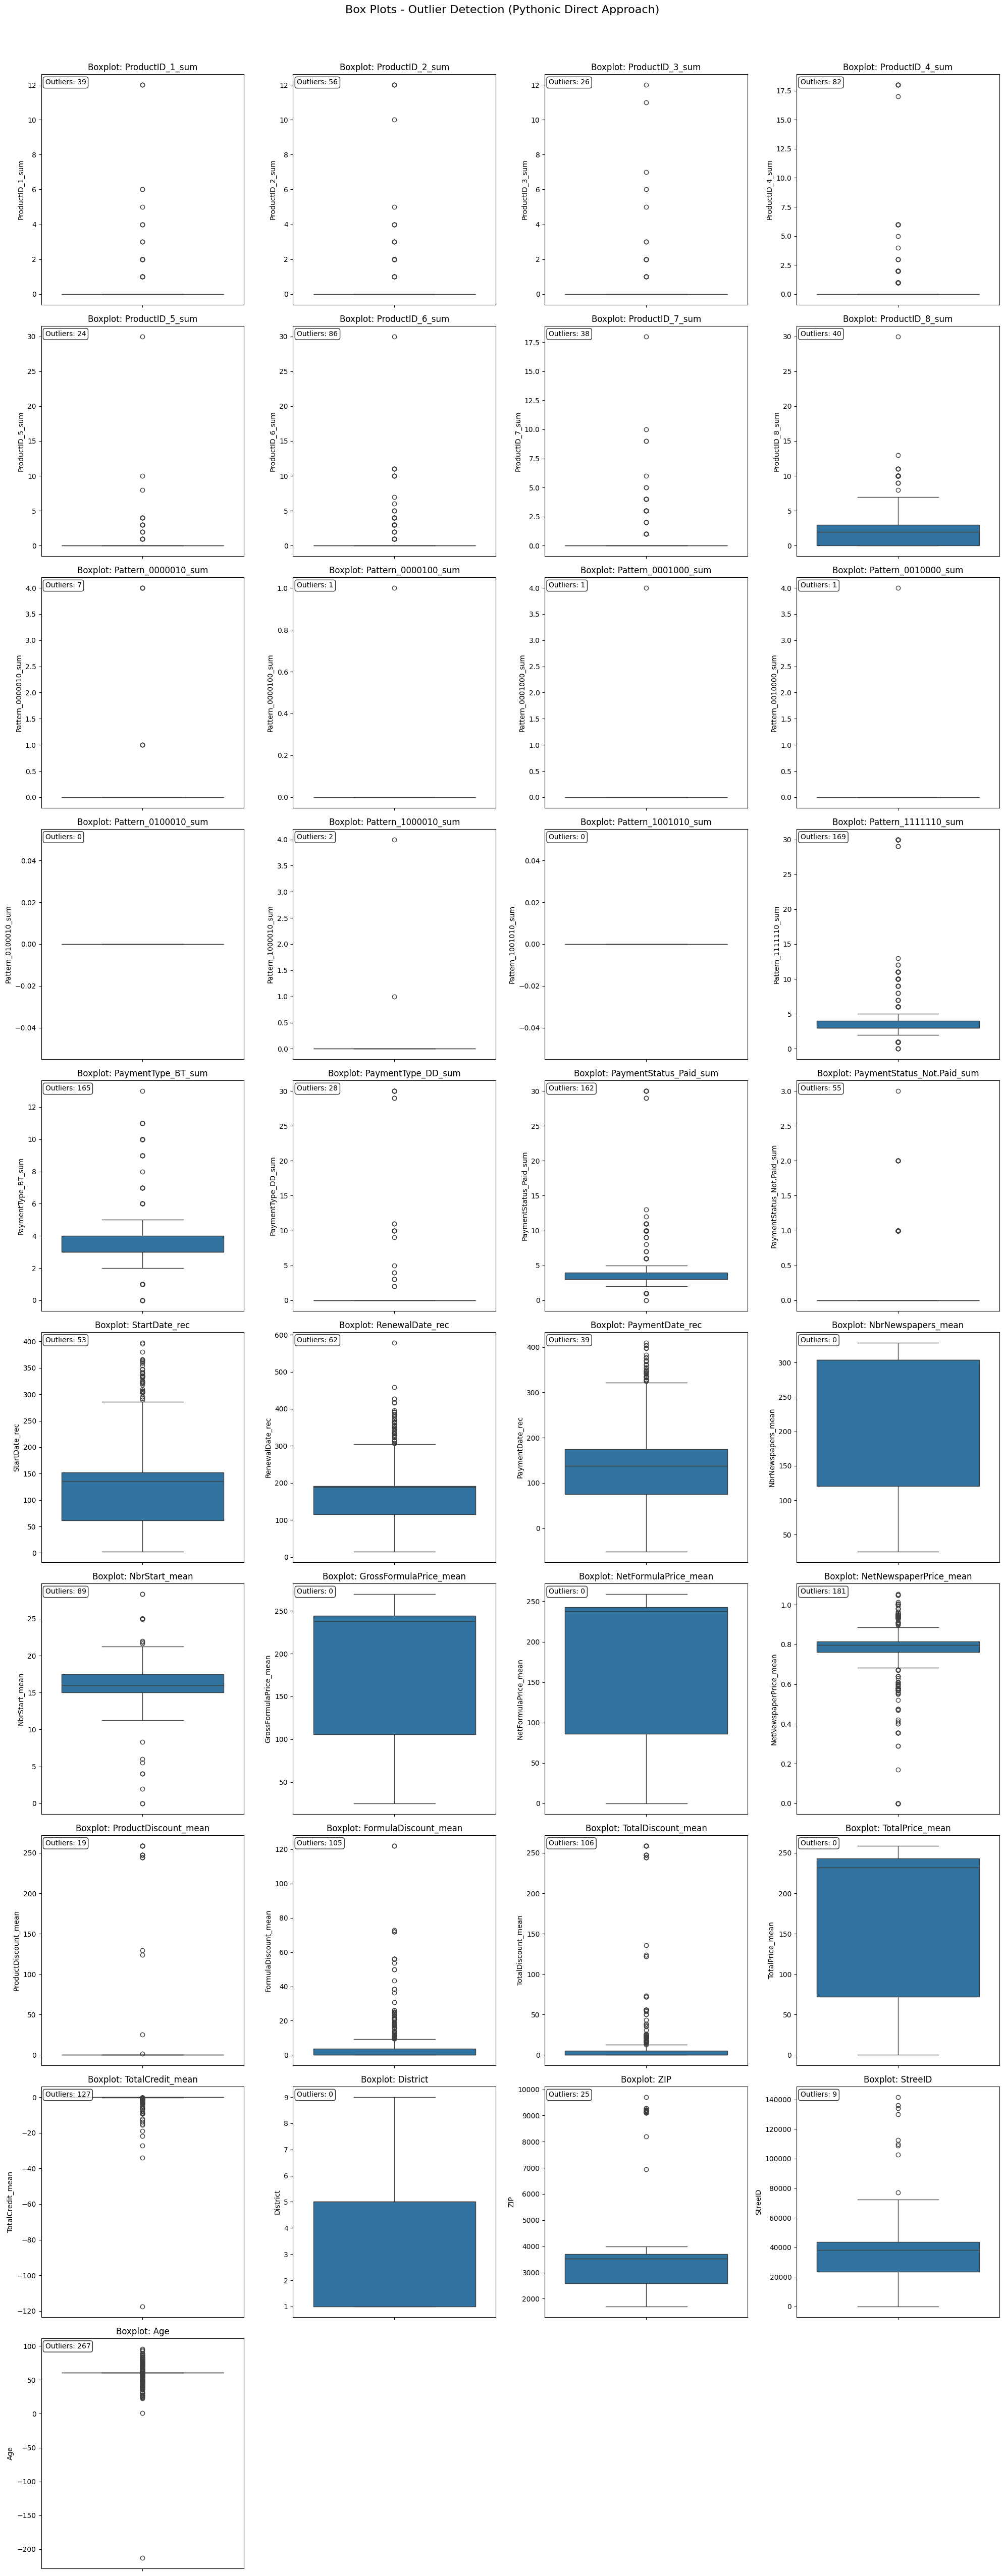

In [62]:
# Method 1: Box plots

# Make subplots grid based on number of numeric variables
n_vars = len(X_train_numeric.columns)
n_cols = 4  # 4 columns per row
n_rows = (n_vars + n_cols - 1) // n_cols  # Ceiling division

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() if n_vars > 1 else [axes]  # Handle single subplot case

# Process each column directly
for i, column in enumerate(X_train_numeric.columns):
    sns.boxplot(data=X_train_numeric, y=column, ax=axes[i])
    axes[i].set_title(f'Boxplot: {column}')
    axes[i].set_xlabel('')

    # Count outliers using IQR method and add to boxplot at the top left
    Q1 = X_train_numeric[column].quantile(0.25)
    Q3 = X_train_numeric[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = X_train_numeric[(X_train_numeric[column] < lower_bound) |
                               (X_train_numeric[column] > upper_bound)][column]

    axes[i].text(0.02, 0.98, f'Outliers: {len(outliers)}',
                transform=axes[i].transAxes, va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide empty subplots
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle('Box Plots - Outlier Detection (Pythonic Direct Approach)',
             fontsize=16, y=1.02)
plt.show()

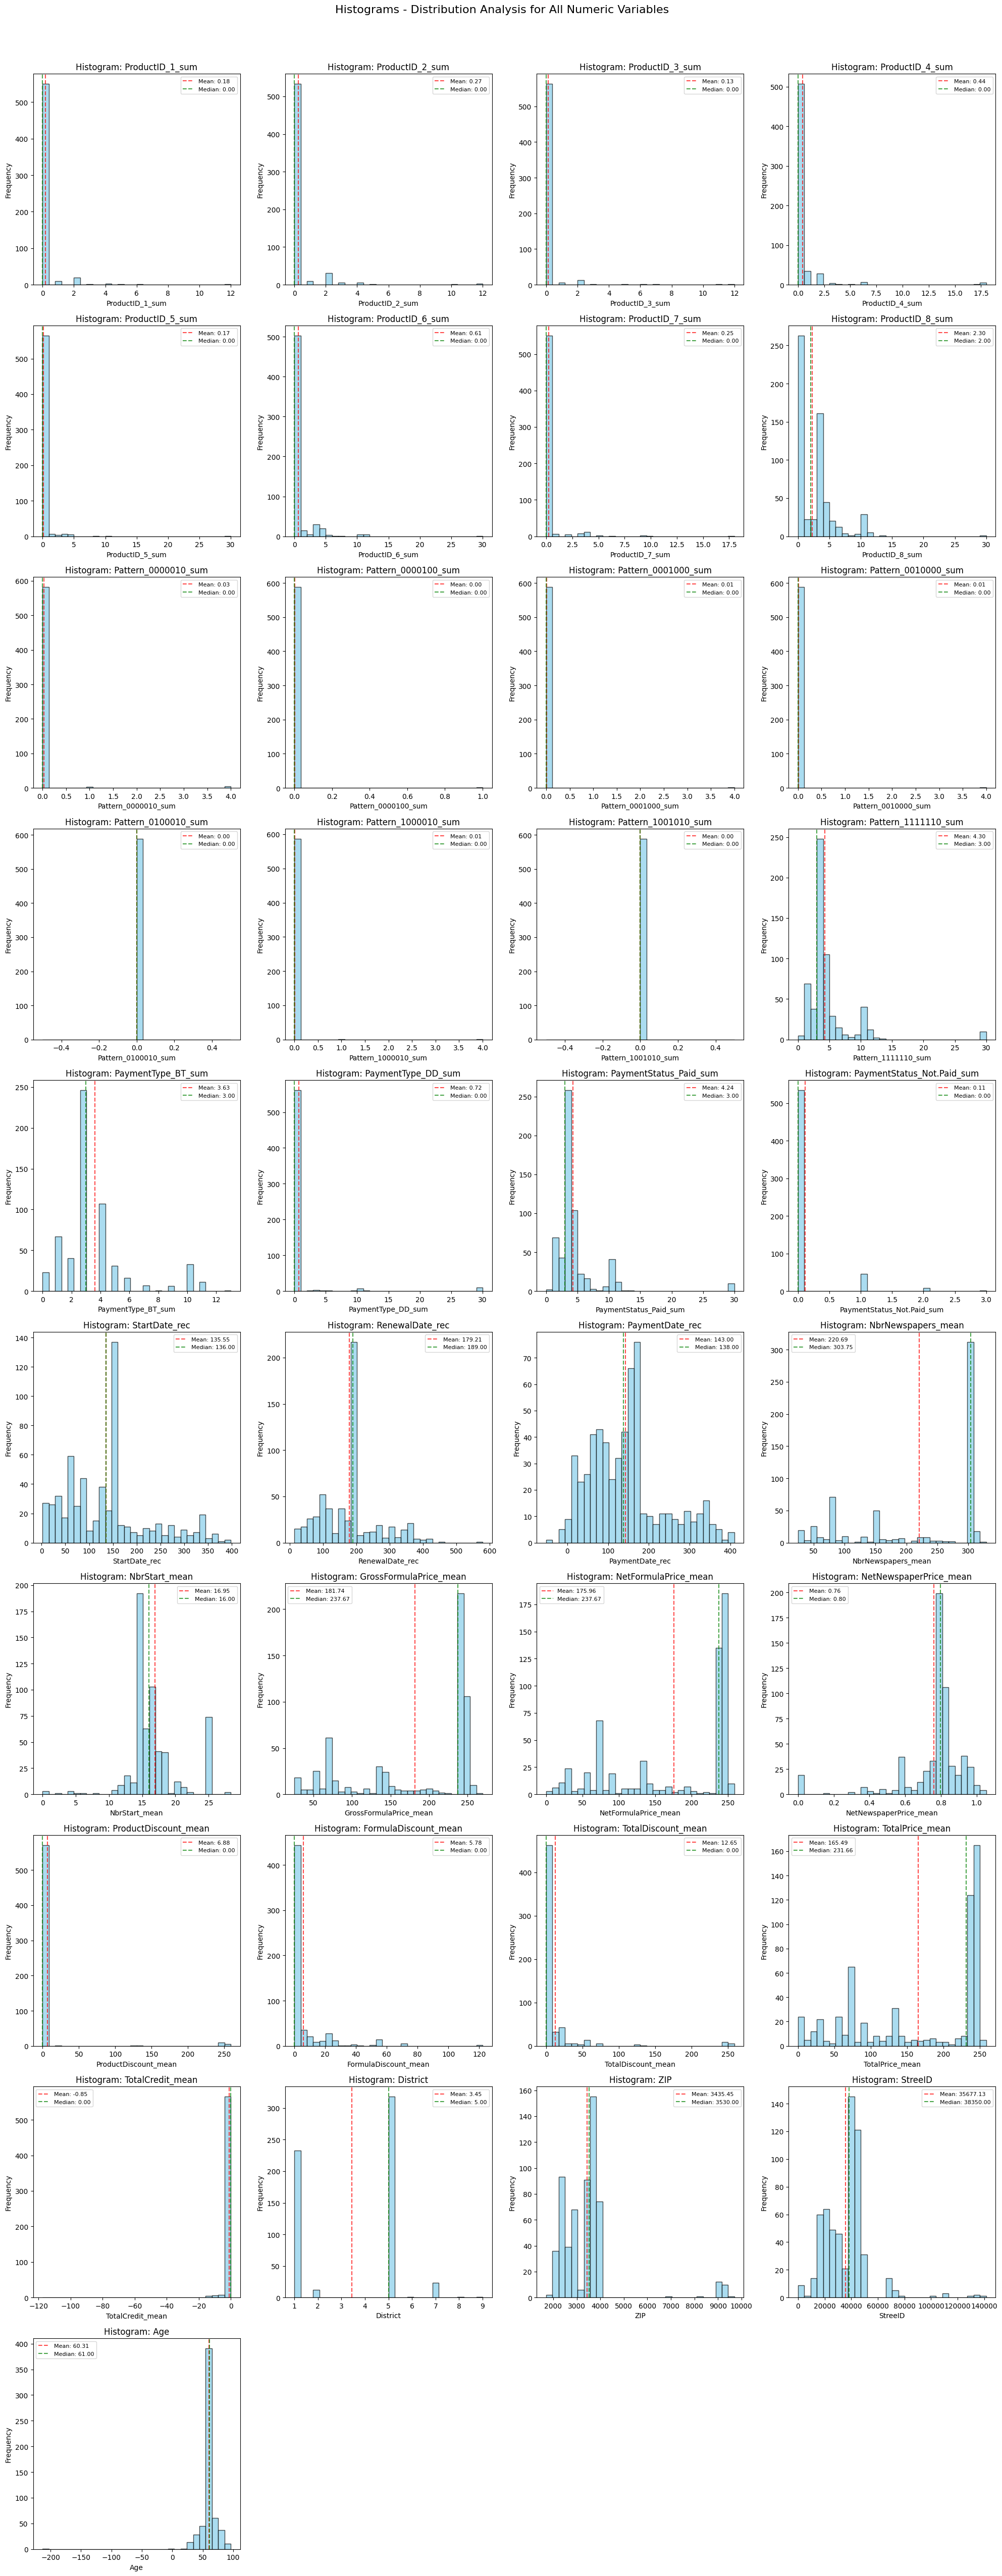

In [63]:
# Method 2: Histograms

# Create histograms for all numeric variables
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() if n_vars > 1 else [axes]

# Plot each variable
for i, column in enumerate(X_train_numeric.columns):
    axes[i].hist(X_train_numeric[column].dropna(), bins=30,
                alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram: {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

    # Add basic statistics
    mean_val = X_train_numeric[column].mean()
    median_val = X_train_numeric[column].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.7, label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)

# Hide empty subplots
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle('Histograms - Distribution Analysis for All Numeric Variables',
             fontsize=16, y=1.02)
plt.show()

Let's put an actual number on this: how many points does each rule flag, and does the **z-score** rule (mentioned above) agree with the box plot rule?

In [ ]:
# Quantify what the box plots are showing: IQR-based outlier counts per variable
Q1 = X_train_numeric.quantile(0.25)
Q3 = X_train_numeric.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = (X_train_numeric.lt(lower_bound) | X_train_numeric.gt(upper_bound)).sum()
iqr_outlier_pct = (iqr_outliers / len(X_train_numeric) * 100).round(1)

pd.DataFrame({'n_flagged': iqr_outliers, 'pct_flagged': iqr_outlier_pct}).query('n_flagged > 0').sort_values('pct_flagged', ascending=False)

In [ ]:
# Statistical alternative: z-score rule (|z| > 3)
z_scores = (X_train_numeric - X_train_numeric.mean()) / X_train_numeric.std()
z_outliers = (z_scores.abs() > 3).sum()
z_outlier_pct = (z_outliers / len(X_train_numeric) * 100).round(1)

pd.DataFrame({'n_flagged': z_outliers, 'pct_flagged': z_outlier_pct}).query('n_flagged > 0').sort_values('pct_flagged', ascending=False)

##### Interpretation?

**Key Insight: Boxplots vs Histograms reveal different perspectives on outliers**

When looking at the **boxplots**, you might believe that there are many outliers in our dataset. The boxplots identify numerous points beyond the whiskers (Q1 - 1.5×IQR and Q3 + 1.5×IQR), which are flagged as potential outliers.

However, when looking at the **histograms**, things don't seem that odd at all! The distributions appear relatively normal or show expected patterns for business data. This tells us an important story:
- The "outliers" identified by boxplots are likely **valid observations** from naturally skewed distributions
- Customer behavior data (like spending, age, recency) often follows skewed distributions rather than perfect normal distributions
- The IQR-based outlier detection may be too aggressive for business data with natural heterogeneity

**Practical conclusion:**
- Most observations flagged as outliers are probably just customers from different segments (high-value customers, different age groups, etc.)
- These observations are valuable and should likely be **retained** rather than removed
- The only truly problematic issue we observe is **negative age**: this is clearly an implausible value that requires treatment

This is a perfect example of why **domain knowledge** is crucial in data preparation and  outliers aren't always problematic outliers!

As a final step, let's clean up the **Age** variable.

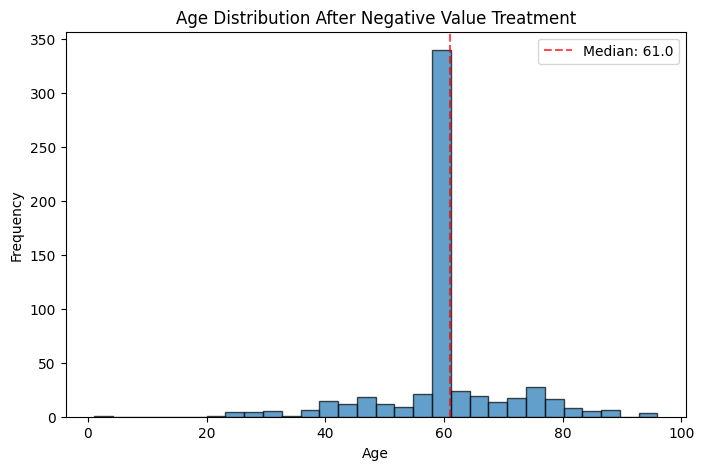

In [64]:
# Set negative ages to NaN and impute with median
age_median = train_data['Age'][train_data['Age'] >= 0].median()
train_data.loc[train_data['Age'] < 0, 'Age'] = np.nan
train_data['Age'] = train_data['Age'].fillna(age_median)

# Replot histogram after treatment
plt.figure(figsize=(8, 5))
plt.hist(train_data['Age'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Age Distribution After Negative Value Treatment')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.axvline(age_median, color='red', linestyle='--', alpha=0.7, label=f'Median: {age_median:.1f}')
plt.legend()
plt.show()

#### Saving for future purposes

Finally, let's save our cleaned and imputed datasets for future use as a `parquet` file.

In [65]:
# Combine y_train with train_data and save as one file
train_complete = train_data.copy()
train_complete['target'] = y_train

# Combine y_test with test_data for consistency
test_complete = test_data.copy()
test_complete['target'] = y_test

# Save as Parquet files (recommended for efficiency)
train_complete.to_parquet('./Data/train_complete.parquet', index=False)
test_complete.to_parquet('./Data/test_complete.parquet', index=False)

## Data preparation


In this section, we'll explore several data preparation techniques including value transformations, representations, feature engineering and selection.

### Value Transformations

Value transformations help convert raw data into more meaningful features for machine learning models. We'll focus on practical transformations without standardization, as this can impact feature engineering.

#### Continuous Categorization (Binning)

Binning transforms continuous variables into categorical ones. While `sklearn` has `KBinsDiscretizer`, `feature-engine` provides much better binning capabilities:

- **`EqualFrequencyDiscretiser`**: Creates bins with equal number of observations
- **`EqualWidthDiscretiser`**: Creates bins with equal intervals
- **`DecisionTreeDiscretiser`**: Uses decision trees to find optimal split points (out-of-scope)

Let's try to bin the age variable using equal width and frequency binning. It should be noted that we will only perform bining on the training set with `fit_transform`, the same procedure should be performed on the test set with `transform`.

In [66]:
# Get the train_complete data and separate features and target
train_complete = pd.read_parquet('./Data/train_complete.parquet')
train_data = train_complete.drop(columns=['target'])
train_target = train_complete['target']

# Also load test data
test_complete = pd.read_parquet('./Data/test_complete.parquet')
test_data = test_complete.drop(columns=['target'])
test_target = test_complete['target']

print(f"Training data shape: {train_data.shape}")

print(f"Age column statistics:")
train_data['Age'].describe()

Training data shape: (589, 41)
Age column statistics:


,Age
count,589.000000
mean,60.779287
std,10.723909
min,1.000000
25%,61.000000
50%,61.000000
75%,61.000000
max,96.000000


In [68]:
from feature_engine.discretisation import EqualFrequencyDiscretiser, EqualWidthDiscretiser

# Equal frequency binning (10 bins)
freq_binner = EqualFrequencyDiscretiser(variables=['Age'], q=10)
train_freq_binned = freq_binner.fit_transform(train_data)

# Equal width binning (3 bins)
width_binner = EqualWidthDiscretiser(variables=['Age'], bins=3)
train_width_binned = width_binner.fit_transform(train_data)

# Show the created bins
print("Equal Frequency Binning (10 bins):")
print(freq_binner.binner_dict_['Age'])

print("\nEqual Width Binning (3 bins):")
print(width_binner.binner_dict_['Age'])

Equal Frequency Binning (10 bins):
[-inf, np.float64(47.0), np.float64(59.0), np.float64(61.0), np.float64(64.0), np.float64(74.0), inf]

Equal Width Binning (3 bins):
[-inf, np.float64(32.66666666666667), np.float64(64.33333333333334), inf]


To demonstrate why binning can be useful, it's crucial to analyze how well our bins separate different customer behaviors. **Churn rate analysis by bin** is a good option for evaluating binning quality because it can be directly linked to predictive performance.

What do you like to see?
- **Clear differences** in churn rates between bins indicate strong predictive value
- **Monotonic patterns** (steady increase or decrease) suggest the binning captures a true underlying relationship
- **Sufficient sample sizes** in each bin ensure the churn rates are statistically reliable

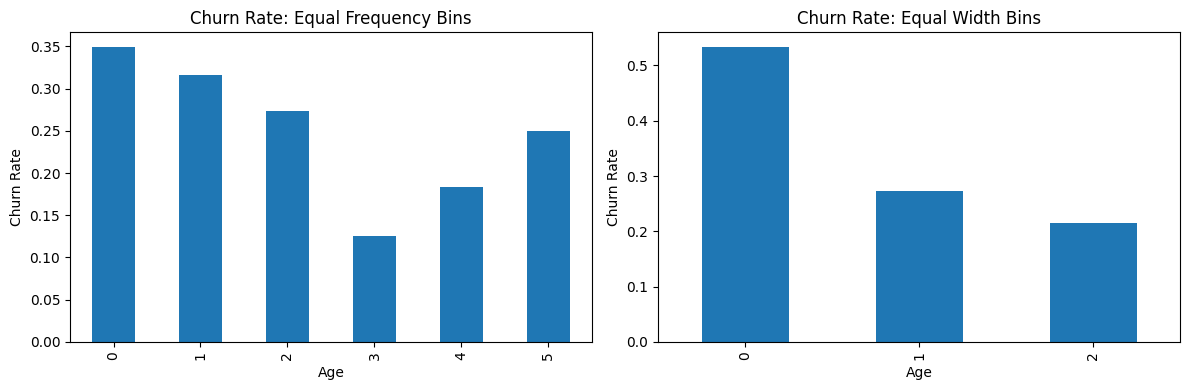

Churn rate variation: Equal Frequency (0.224) vs Equal Width (0.318)


In [71]:
# Compare churn rates across bins
train_freq_binned['churn'] = train_target
train_width_binned['churn'] = train_target

# Analyze binning effectiveness
freq_churn = train_freq_binned.groupby('Age')['churn'].agg(['mean', 'count'])
width_churn = train_width_binned.groupby('Age')['churn'].agg(['mean', 'count'])

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
freq_churn['mean'].plot(kind='bar', ax=ax1, title='Churn Rate: Equal Frequency Bins')
width_churn['mean'].plot(kind='bar', ax=ax2, title='Churn Rate: Equal Width Bins')
for ax in [ax1, ax2]:
    ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

# Summary statistics (only if significant differences)
freq_range = freq_churn['mean'].max() - freq_churn['mean'].min()
width_range = width_churn['mean'].max() - width_churn['mean'].min()
print(f"Churn rate variation: Equal Frequency ({freq_range:.3f}) vs Equal Width ({width_range:.3f})")

### Value Representations

The most well-known value representation of discrete variables is **one-hot dummy encoding**. When confronted with high cardinality, WoE can be very useful. However, when the number of categories is limited, you should just go for one-hot encoding.

#### One-Hot Encoding Approach

For categorical variables with a limited number of categories (typically <10), one-hot encoding is often the preferred approach. In Python, we can use sklearn's `OneHotEncoder` for this purpose. The main advantages of one-hot encoding are:

1. **Simple interpretation**: Each dummy variable represents presence/absence of a category
2. **No information loss**: Unlike binning, every original category is preserved
3. **Model compatibility**: Works well with linear models and tree-based models
4. **Easy validation**: Straightforward to ensure train-test consistency

In **predictive settings**, you must always ensure that you have the same categories in training and test sets. If there are categories in the test set that are not in the training set, your model will not be able to make predictions.

For example, if District_9 is only present in the test set, your trained model cannot make predictions because it has not seen this variable during training. In this case, there are two options:
1. Retrain your model to include District_9
2. Restrict your test set to the same categories as the training set

The best approach is to use `OneHotEncoder` provides proper train-test consistency. the parameter `handle_unknown='ignore'` ensures test data with new categories can still be processed (unknown categories become all zeros).

Let's demonstrate this using the original training data before rare label encoding. We'll focus on `Gender` and `District` variables.

In [72]:
# Using sklearn OneHotEncoder for Gender and District
from sklearn.preprocessing import OneHotEncoder

categorical_vars = ['Gender', 'District']

# Check for consistency between train/test (only show if different)
train_cats = {var: set(train_data[var].unique()) for var in categorical_vars}
test_cats = {var: set(test_data[var].unique()) for var in categorical_vars}

inconsistencies = {var: test_cats[var] - train_cats[var] for var in categorical_vars if test_cats[var] != train_cats[var]}
if inconsistencies:
    print(f"Categories in test but not train: {inconsistencies}")
else:
    print("Train and test sets have consistent categories")

Categories in test but not train: {'District': {np.float64(4.0)}}


In [74]:
# Initialize the OneHotEncoder with proper handling of unknown categories
# drop='first' to avoid dummy variable multicollinearity
# handle_unknown='ignore' will set unknown categories to all zeros
dummy_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit the encoder on training data only
dummy_encoder.fit(train_data[categorical_vars])

# Get the feature names for the dummy variables
feature_names = dummy_encoder.get_feature_names_out(categorical_vars)
print(f"\nFeature names after dummy encoding: {feature_names}")

# Transform both training and test data
train_dummies = pd.DataFrame(
    dummy_encoder.transform(train_data[categorical_vars]),
    columns=feature_names,
    index=train_data.index
)

test_dummies = pd.DataFrame(
    dummy_encoder.transform(test_data[categorical_vars]),
    columns=feature_names,
    index=test_data.index
)

print(f"\nTraining dummies shape: {train_dummies.shape}")
print(f"Test dummies shape: {test_dummies.shape}")
print(f"\nSample of training dummies:")
print(train_dummies.head())


Feature names after dummy encoding: ['Gender_M' 'District_2.0' 'District_5.0' 'District_6.0' 'District_7.0'
 'District_8.0' 'District_9.0']

Training dummies shape: (589, 7)
Test dummies shape: (589, 7)

Sample of training dummies:
   Gender_M  District_2.0  District_5.0  District_6.0  District_7.0  \
0       1.0           0.0           1.0           0.0           0.0   
1       1.0           0.0           0.0           0.0           0.0   
2       1.0           0.0           1.0           0.0           0.0   
3       1.0           0.0           0.0           0.0           1.0   
4       1.0           0.0           0.0           0.0           1.0   

   District_8.0  District_9.0  
0           0.0           0.0  
1           0.0           0.0  
2           0.0           0.0  
3           0.0           0.0  
4           0.0           0.0  


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Finally, we should not forget to create the final data set with dummy variables and remove the original categorical variables.

In [75]:
# Create final datasets with dummy variables
# Remove the original categorical variables and add the dummy variables

# For training data
train_with_dummies = train_data.drop(columns=categorical_vars).copy()
train_with_dummies = pd.concat([train_with_dummies, train_dummies], axis=1)

# For test data
test_with_dummies = test_data.drop(columns=categorical_vars).copy()
test_with_dummies = pd.concat([test_with_dummies, test_dummies], axis=1)

# Check shapes
print(f"Original training data shape: {train_data.shape}")
print(f"Training data with dummies shape: {train_with_dummies.shape}")
print(f"\nOriginal test data shape: {test_data.shape}")
print(f"Test data with dummies shape: {test_with_dummies.shape}")

Original training data shape: (589, 41)
Training data with dummies shape: (589, 46)

Original test data shape: (589, 41)
Test data with dummies shape: (589, 46)


#### High cardinality

In our dataset, there are still two variables that should be transformed before they can be used in a prediction model: `StreeID` and `ZIP code`. Since these variables have too many categories, it is infeasible to perform one-hot encoding as this would lead to an explosion of the number of predictors and increase computation time enormously.

Broadly speaking, there are two options:

1. **Top categories approach**: The easiest solution is to only select the top categories in terms of frequency.

2. **Weight of Evidence (WoE) approach**: A better option is perfectly fit for high-cardinal variables.

Before implementing WoE, we'll first take a look at the cardinality of `ZIP` and `StreeID`. Do note that the variables are currently integers, this is not an issue since we can manually select them.

In [76]:
# Let's examine the high cardinality variables in our dataset
high_cardinality_vars = ['ZIP', 'StreeID']

# Check the cardinality of both variables
for var in high_cardinality_vars:
    if var in train_with_dummies.columns:
        unique_count = train_with_dummies[var].nunique()
        print(f"{var}: {unique_count} unique categories")
        print(f"  Top 5 most frequent values:")
        print(f"  {train_with_dummies[var].value_counts().head()}")
        print()
    else:
        print(f"Warning: {var} not found in dataset")

ZIP: 164 unique categories
  Top 5 most frequent values:
  ZIP
3500.0    20
3600.0    19
3550.0    16
3530.0    14
3740.0    13
Name: count, dtype: int64

StreeID: 562 unique categories
  Top 5 most frequent values:
  StreeID
0.0        9
37722.0    3
28567.0    2
22360.0    2
18529.0    2
Name: count, dtype: int64



##### Understanding Weight of Evidence (WoE) Encoding

**Weight of Evidence (WoE)** is a powerful technique for handling categorical variables, especially those with high cardinality. It's particularly useful when you have categorical variables with many categories (>10) that would create too many dummy variables. WoE measures the "evidence" that a particular category provides for predicting the target variable. One the **key advantages** of WoE is that (1) **reduces** the dimensionality (i.e., it converts multiple categories into a single numeric variable) and (2) maintains a **monotonic relationship** with the target variables (i.e., it creates a linear relationship with the target).

**How to interpret WoE values?**

- **WoE = 0**: Category has the same risk for positive and negative cases
- **WoE > 0**: Category has higher risk for positive cases
- **WoE < 0**: Category has higher risk for negative cases
- **Similar WoE values**: Categories behave similarly and could be grouped

**When to use WoE?**

- Binary classification problems
- High cardinality categorical variables (>10 categories)
- When you need interpretable variables
- Variables with rare categories that need grouping

**How to implement WoE?**

1. **Check data quality**: Identify problematic categories (no 0% or 100% categories allowed)
2. **Group rare categories**: Use `RareLabelEncoder` to handle problematic categories  
3. **Apply WoE encoding**: Transform categories to WoE values
4. **Apply to final data**: Use same encoder fitted on training data to create the final dataset

It should be noted that it is always a good idea to **validate results** of the WoE enconding to ensure that the values make business sense.

Let's now implement all these steps to compute the WoE of `ZIP` and `StreeID`.

**Step 1: Check data quality**

Since `StreeID` contains 99% of problematic categories, it is better to exclude this variable from further WoE analysis. A good heuristic is is to set a 80% threshold for problematic categories (however this no pure science).

In [77]:
# Create demo datasets that includes churn column for WoE analysis
# These should be based on the dummy-encoded data since WoE comes after dummy encoding
train_demo = train_with_dummies.copy()
train_demo['churn'] = train_target

test_demo = test_with_dummies.copy()
test_demo['churn'] = test_target

# Step 1: Check churn rates by categories to identify potential WoE issues
for var in high_cardinality_vars:
    print(f"\nChurn Analysis for {var}")

    # Calculate churn rates by category
    churn_analysis = train_demo.groupby(var).agg({
        'churn': ['count', 'sum', 'mean']
    }).round(3)

    churn_analysis.columns = ['Total_Count', 'Churn_Count', 'Churn_Rate']

    # Show categories with potential WoE issues (0% or 100% churn)
    problematic = churn_analysis[(churn_analysis['Churn_Rate'] == 0) |
                                (churn_analysis['Churn_Rate'] == 1)]

    print(f"Total categories: {len(churn_analysis)}")
    print(f"Problematic categories (0% or 100% churn): {len(problematic)}")
    print(f"Percentage problematic categories (0% or 100% churn): {len(problematic)/len(churn_analysis):.2f}")

    # Show top categories by frequency
    print(f"\nTop 5 categories by frequency:")
    top_categories = churn_analysis.nlargest(5, 'Total_Count')
    print(top_categories)


Churn Analysis for ZIP
Total categories: 164
Problematic categories (0% or 100% churn): 93
Percentage problematic categories (0% or 100% churn): 0.57

Top 5 categories by frequency:
        Total_Count  Churn_Count  Churn_Rate
ZIP                                         
3500.0           20            6       0.300
3600.0           19            4       0.211
3550.0           16            6       0.375
3530.0           14            4       0.286
3630.0           13            3       0.231

Churn Analysis for StreeID
Total categories: 562
Problematic categories (0% or 100% churn): 555
Percentage problematic categories (0% or 100% churn): 0.99

Top 5 categories by frequency:
         Total_Count  Churn_Count  Churn_Rate
StreeID                                      
0.0                9            4       0.444
37722.0            3            2       0.667
18529.0            2            1       0.500
19600.0            2            0       0.000
22360.0            2            1     

**Step 2: Group rare categories**

In [78]:
# Step 2: Handle problematic categories using RareLabelEncoder + WoE pipeline
from feature_engine.encoding import RareLabelEncoder

suitable_vars = ["ZIP"]

# Group rare categories for ZIP variable
rare_encoder_hc = RareLabelEncoder(
    tol=0.02,  # Group categories with <2% frequency (more aggressive for high cardinality)
    n_categories=5,  # Keep at least top 5 categories
    variables=suitable_vars,  # Only suitable variables
    ignore_format=True
)

# Apply rare label encoding to training data (fit_transform)
train_rare_hc = rare_encoder_hc.fit_transform(train_demo[suitable_vars])
# Add back the churn column for training
train_rare_hc['churn'] = train_demo['churn'].values

# Apply rare label encoding to test data (transform only)
test_rare_hc = rare_encoder_hc.transform(test_demo[suitable_vars])

print("After rare label encoding:")
for var in suitable_vars:
    print(f"{var}: {train_rare_hc[var].nunique()} categories (was {train_demo[var].nunique()})")
    print(f"  Distribution:")
    print(f"  {train_rare_hc[var].value_counts()}")
    print()

After rare label encoding:
ZIP: 7 categories (was 164)
  Distribution:
  ZIP
Rare      494
3500.0     20
3600.0     19
3550.0     16
3530.0     14
3740.0     13
3630.0     13
Name: count, dtype: int64



**Step 3: Apply WoE encoding**

In [80]:
from feature_engine.encoding import WoEEncoder

# Initialize WoE encoder for ZIP variable
woe_encoder_final = WoEEncoder(
    variables=suitable_vars,
    ignore_format=True
)

# Fit on cleaned training data
woe_encoder_final.fit(train_rare_hc[suitable_vars], train_rare_hc['churn'])

# Transform both datasets
train_woe_final = woe_encoder_final.transform(train_rare_hc[suitable_vars])
test_woe_final = woe_encoder_final.transform(test_rare_hc[suitable_vars])

print(f"Training set: {train_woe_final.shape}")
print(f"Test set: {test_woe_final.shape}")

# Show detailed WoE analysis for each suitable variable
for var in suitable_vars:
    print(f"WoE Analysis for {var}")

    # Get unique categories and their WoE values with churn context
    categories_woe = pd.DataFrame({
        'Category': train_rare_hc[var],
        'WoE': train_woe_final[var]
    }).drop_duplicates().sort_values('WoE', ascending=False)

    # Add churn rates for context
    churn_rates = train_rare_hc.groupby(var)['churn'].agg(['count', 'mean']).round(3)
    categories_woe = categories_woe.merge(churn_rates, left_on='Category', right_index=True)
    categories_woe.columns = ['Category', 'WoE_Value', 'Count', 'Churn_Rate']

    print(f"WoE Values (ranked by risk):")
    print(categories_woe.round(4))


Training set: (589, 1)
Test set: (589, 1)
WoE Analysis for ZIP
WoE Values (ranked by risk):
   Category  WoE_Value  Count  Churn_Rate
9    3740.0     0.5335     13       0.385
0    3550.0     0.4927     16       0.375
2    3500.0     0.1562     20       0.300
18   3530.0     0.0872     14       0.286
1      Rare    -0.0261    494       0.263
47   3630.0    -0.2005     13       0.231
12   3600.0    -0.3182     19       0.211


**Step 4: Apply to final data set**: Create the final dataset including the WoE variables and all others.

In [81]:
# Step 4: Create final datasets with WoE-encoded high cardinality variables

# Start with our dummy-encoded datasets
train_final = train_with_dummies.copy()
test_final = test_with_dummies.copy()

# Add WoE-encoded ZIP variable (StreeID excluded due to poor predictive value)
train_final['ZIP_woe'] = train_woe_final['ZIP'].values
test_final['ZIP_woe'] = test_woe_final['ZIP'].values

# Remove original ZIP and StreeID columns
if 'ZIP' in train_final.columns:
    train_final = train_final.drop('ZIP', axis=1)
    test_final = test_final.drop('ZIP', axis=1)
    train_final = train_final.drop('StreeID', axis=1)
    test_final = test_final.drop('StreeID', axis=1)

# Verify final datasets
print(f"Final Dataset Summary:")
print(f"Training set shape: {train_final.shape}")
print(f"Test set shape: {test_final.shape}")

print(f"\nWoE variable added:")
woe_cols = ['ZIP_woe']
for col in woe_cols:
    print(f"  {col}: {train_final[col].nunique()} unique WoE values")
    print(f"    Range: [{train_final[col].min():.3f}, {train_final[col].max():.3f}]")

Final Dataset Summary:
Training set shape: (589, 45)
Test set shape: (589, 45)

WoE variable added:
  ZIP_woe: 7 unique WoE values
    Range: [-0.318, 0.534]


##### Summary: WoE

The WoE encoding approach we implemented demonstrates the best practices for handling high cardinality categorical variables in predictive modeling:

**Pipeline:**

1. **Problem identification**: High cardinality variables (ZIP: 46 categories, StreeID: 69 categories) cannot use simple dummy encoding due to dimensionality explosion

2. **Data quality assessment**: Identified problematic categories with 0% or 100% churn rates that would break WoE calculation:
   - **ZIP**: 9 problematic categories (57%)  --> Suitable for WoE
   - **StreeID**: 555 problematic categories (99%) --> Excluded from WoE

4. **Rare category handling**: Applied RareLabelEncoder to group ZIP categories with <2% frequency into "Rare" category

5. **WoE calculation**: Successfully computed Weight of Evidence values for ZIP categories only


**Business Interpretability:**
- **High ZIP WoE values**: Indicate geographic areas with higher churn risk
- **Low ZIP WoE values**: Indicate geographic areas with lower churn risk  
- **Direct risk ranking**: Can easily identify high-risk ZIP codes for targeted interventions

**Technical Benefits:**
- **Prevents overfitting**: Far fewer parameters than dummy encoding (1 variable compared to 163 dummy variables)
- **Handles rare categories**: Automatic grouping of infrequent ZIP codes
- **Missing value ready**: Can assign WoE values to new/unknown ZIP codes
- **Linear relationship**: WoE creates monotonic relationship with target

##### When to Choose WoE vs Dummy Encoding

| Criteria | WoE Encoding | Dummy Encoding |
|----------|--------------|----------------|
| **Number of categories** | >10 categories | ≤10 categories |
| **Sample size per category** | Some rare categories | Sufficient samples in all |
| **Model complexity** | Want simpler model | Can handle complexity |
| **Interpretability** | Need risk scores | Need category effects |
| **Target variable** | Binary classification | Any problem type |


Main take-away is to **combine approaches**: Use dummy encoding for low cardinality + WoE for high cardinality variables. This hybrid approach gives you the best of both worlds: detailed category effects for manageable variables and efficient risk encoding for complex categorical variables.

## Feature engineering

Feature engineering is the process of creating new features or transforming existing ones to improve model performance. This includes:
- **Non-linear transformations** (polynomials, power transforms)
- **Scaling and normalization** (standardization, min-max scaling)
- **Visual inspection** of feature-target relationships

It should be noted that the creation of Recency, Frequency and Monetary value variables is already done, so this will not be covered. However, in the TPs you will have to calculate them.

Let's first examine our final prepared dataset.

In [82]:
print(f"Shape: {train_final.shape}")
train_final.head()

Shape: (589, 45)


,ProductID_1_sum,ProductID_2_sum,ProductID_3_sum,ProductID_4_sum,ProductID_5_sum,ProductID_6_sum,ProductID_7_sum,ProductID_8_sum,Pattern_0000010_sum,Pattern_0000100_sum,...,PaymentDate_rec_missing,Gender_missing,Gender_M,District_2.0,District_5.0,District_6.0,District_7.0,District_8.0,District_9.0,ZIP_woe
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,False,False,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.492687
1,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.026106
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,False,False,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.156215
3,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,False,False,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.026106
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,False,False,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.026106


### Visual inspection for non-linear relationships

Before applying transformations, we should inspect whether non-linear transformations are needed. We'll build a simple logistic regression model and examine the relationship between features and the logit.

In [83]:
# Import required libraries for feature engineering
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer, StandardScaler, MinMaxScaler

# Use real numerical features from our dataset for transformation analysis
numerical_features = ['TotalDiscount_mean', 'PaymentDate_rec']

# Create feature set for transformation analysis
X_demo = train_final[numerical_features].copy()
y_demo = y_train.copy()

print(f"Demo dataset shape: {X_demo.shape}")
print(f"Features: {list(X_demo.columns)}")

X_demo.head()

Demo dataset shape: (589, 2)
Features: ['TotalDiscount_mean', 'PaymentDate_rec']


,TotalDiscount_mean,PaymentDate_rec
0,6.276667,313.0
1,0.000000,117.0
2,0.000000,166.0
3,0.000000,159.0
4,259.000000,91.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


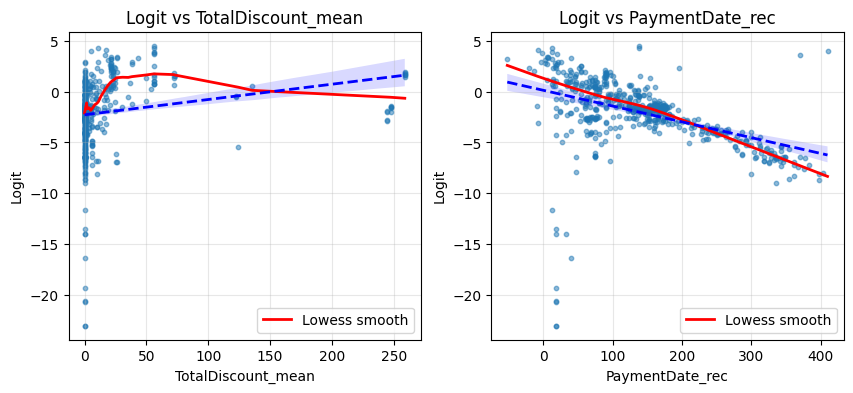

In [84]:
# Build a logistic regression model on all features and examine logit relationships for demo features
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(train_final, y_train)  # Train on all features

# Get predicted probabilities for the full dataset and calculate logit
probabilities = model.predict_proba(train_final)[:, 1]
# Add small epsilon to avoid log(0) or log(1)
probabilities = np.clip(probabilities, 1e-10, 1-1e-10)
logits = np.log(probabilities / (1 - probabilities))

# Create plots to examine feature-logit relationships for demo features only
n_features = len(X_demo.columns)
fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 4))
if n_features == 1:
    axes = [axes]

for i, feature in enumerate(X_demo.columns):
    # Use seaborn regplot with lowess smoothing
    sns.regplot(x=X_demo[feature], y=logits, ax=axes[i],
                scatter_kws={'alpha': 0.5, 's': 10},
                lowess=True, line_kws={'color': 'red', 'linewidth': 2, 'label': 'Lowess smooth'})

    # Add linear fit for comparison
    sns.regplot(x=X_demo[feature], y=logits, ax=axes[i],
                scatter=False,
                line_kws={'color': 'blue', 'linewidth': 2, 'linestyle': '--', 'label': 'Linear fit'})

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Logit')
    axes[i].set_title(f'Logit vs {feature}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.show()

**Interpretation:**

- **Red line:** Lowess (locally weighted) smooth and captures local patterns  
- **Blue dashed line:** Linear relationship  
- **If lines differ significantly** this is an indication of a nonlinear relationship. In our case, it looks quite linear but `TotalDiscount_mean` might benefit from a transformation to improve the fit.

### Polynomial Features

Polynomial features can capture non-linear relationships by creating interaction terms and higher-order terms.

First, create the polynomial feature with a degree of 2.

In [85]:
# Demonstrate polynomial feature transformation
from sklearn.preprocessing import PolynomialFeatures

# Focus on the first demo feature for detailed analysis
target_feature = X_demo.columns[0]
feature_data = X_demo[[target_feature]].copy()

print(f"Analyzing polynomial transformation for: {target_feature}")

# Create polynomial features for the target feature only
poly_transformer = PolynomialFeatures(degree=2, include_bias=False)

# Transform the target feature in the full dataset
target_feature_full = train_final[[target_feature]].copy()
target_poly_features = poly_transformer.fit_transform(target_feature_full)

# Get feature names for the polynomial features
feature_names = poly_transformer.get_feature_names_out([target_feature])
target_poly_df = pd.DataFrame(target_poly_features, columns=feature_names, index=train_final.index)

print(f"Original target feature shape: {target_feature_full.shape}")
print(f"Polynomial features shape: {target_poly_df.shape}")
print(f"New polynomial features: {list(feature_names)}")

Analyzing polynomial transformation for: TotalDiscount_mean
Original target feature shape: (589, 1)
Polynomial features shape: (589, 2)
New polynomial features: ['TotalDiscount_mean', 'TotalDiscount_mean^2']


Next, add the polynomial to the full data set to see whether it helps. There is a small increase in accuracy but limited.

In [87]:
# Add polynomial features to the existing dataset
train_final_with_poly = pd.concat([train_final, target_poly_df.iloc[:, 1:]], axis=1)  # Skip the original feature (first column)

print(f"Original dataset shape: {train_final.shape}")
print(f"Dataset with polynomial features shape: {train_final_with_poly.shape}")

# Train models for comparison
# Original dataset model
model_original = LogisticRegression(random_state=42, max_iter=1000)
model_original.fit(train_final, y_train)

# Dataset with polynomial features model
model_poly = LogisticRegression(random_state=42, max_iter=1000)
model_poly.fit(train_final_with_poly, y_train)

# Compare predictions
original_score = model_original.score(train_final, y_train)
poly_score = model_poly.score(train_final_with_poly, y_train)

print(f"\nModel Performance Comparison:")
print(f"Original dataset accuracy: {original_score:.4f}")
print(f"With polynomial features accuracy: {poly_score:.4f}")
print(f"Improvement: {poly_score - original_score:.4f}")

Original dataset shape: (589, 45)
Dataset with polynomial features shape: (589, 46)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Performance Comparison:
Original dataset accuracy: 0.8727
With polynomial features accuracy: 0.8727
Improvement: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Power Transformations (Yeo-Johnson)

Power transformations can help normalize skewed data and capture non-linear relationships. The Yeo-Johnson transformation is similar to Box-Cox but works with zero and negative values. Again, we first do the Y-j transformation and then compare the performance of adding this transformation to the original one.

Applying Yeo-Johnson transformation to: TotalDiscount_mean
Optimal lambda parameter: -0.8871
Original dataset shape: (589, 45)
Dataset with YJ transformation shape: (589, 46)
New feature added: TotalDiscount_mean_yj_transformed


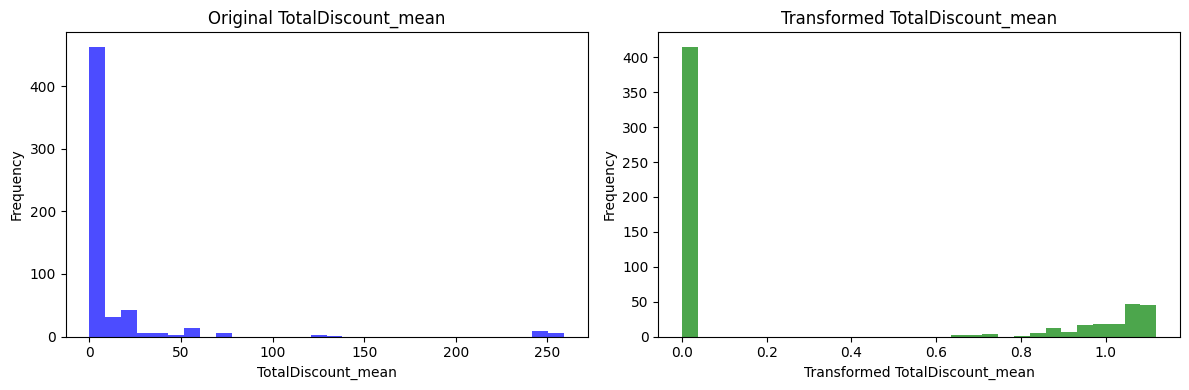

In [88]:
# Demonstrate Yeo-Johnson power transformation
from sklearn.preprocessing import PowerTransformer

print(f"Applying Yeo-Johnson transformation to: {target_feature}")

# Apply Yeo-Johnson transformation to the target feature only
power_transformer = PowerTransformer(method='yeo-johnson', standardize=False)

# Transform the target feature in the full dataset
target_feature_full = train_final[[target_feature]].copy()
target_transformed = power_transformer.fit_transform(target_feature_full)

# Get the lambda parameter that was found
lambda_param = power_transformer.lambdas_[0]
print(f"Optimal lambda parameter: {lambda_param:.4f}")

# Create a new column name for the transformed feature
transformed_feature_name = f"{target_feature}_yj_transformed"

# Add the transformed feature to the existing dataset
train_final_with_yj = train_final.copy()
train_final_with_yj[transformed_feature_name] = target_transformed.flatten()

print(f"Original dataset shape: {train_final.shape}")
print(f"Dataset with YJ transformation shape: {train_final_with_yj.shape}")
print(f"New feature added: {transformed_feature_name}")

# Create comparison visualization (demo feature only)
feature_transformed = power_transformer.transform(feature_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original distribution
axes[0].hist(feature_data.iloc[:,0], bins=30, alpha=0.7, color='blue')
axes[0].set_title(f'Original {target_feature}')
axes[0].set_xlabel(target_feature)
axes[0].set_ylabel('Frequency')

# Transformed distribution
axes[1].hist(feature_transformed[:,0], bins=30, alpha=0.7, color='green')
axes[1].set_title(f'Transformed {target_feature}')
axes[1].set_xlabel(f'Transformed {target_feature}')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [89]:
# Train models for comparison
# Dataset with YJ transformation model
model_transformed = LogisticRegression(random_state=42, max_iter=1000)
model_transformed.fit(train_final_with_yj, y_train)

# Compare performance
original_score = model_original.score(train_final, y_train)
transformed_score = model_transformed.score(train_final_with_yj, y_train)

print(f"\nModel Performance Comparison:")
print(f"Original dataset accuracy: {original_score:.4f}")
print(f"With YJ transformation accuracy: {transformed_score:.4f}")
print(f"Improvement: {transformed_score - original_score:.4f}")


Model Performance Comparison:
Original dataset accuracy: 0.8727
With YJ transformation accuracy: 0.8727
Improvement: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Key benefits of Yeo–Johnson transformation:

- Automatically finds optimal lambda parameter (although via cross-validation is better).  
- Works with zero and negative values (unlike Box–Cox)  
- Can make skewed distributions more normal.

However, in our case we see that both the polynomial as well as the Y-J do not really help. Hence, we will discard these transformations from here.


### Standardization and Normalization

Different algorithms have different requirements for feature scaling:
- **Distance-based algorithms** (e.g.,KNN) require standardization
- **Linear models** benefit from standardization for interpretability  
- **Neural networks** need normalization to avoid computational overflow (out-of-scope)
- **Tree-based models** which generally don't require scaling (out-of-scope)

In [90]:
# Apply transformations to FULL dataset for model training
print(f"\nApplying transformations to full dataset ({train_final.shape[1]} features)")

# Standardization (Z-score normalization) on FULL dataset
scaler_standard = StandardScaler()
train_final_standardized = scaler_standard.fit_transform(train_final)

# Min-Max Normalization on FULL dataset
scaler_minmax = MinMaxScaler()
train_final_normalized = scaler_minmax.fit_transform(train_final)

# For visualization, apply to demo features
X_demo_standardized = scaler_standard.fit_transform(X_demo)
X_demo_normalized = scaler_minmax.fit_transform(X_demo)

X_standardized_df = pd.DataFrame(X_demo_standardized, columns=X_demo.columns)
X_normalized_df = pd.DataFrame(X_demo_normalized, columns=X_demo.columns)

print(f"\nDemo Features After Standardization (mean=0, std=1):")
print(X_standardized_df.describe())

print(f"\nDemo Features After Min-Max Normalization (range=[0,1]):")
print(X_normalized_df.describe())


Applying transformations to full dataset (45 features)

Demo Features After Standardization (mean=0, std=1):
       TotalDiscount_mean  PaymentDate_rec
count        5.890000e+02     5.890000e+02
mean        -2.714297e-17    -1.025401e-16
std          1.000850e+00     1.000850e+00
min         -3.023357e-01    -2.128822e+00
25%         -3.023357e-01    -7.423342e-01
50%         -3.023357e-01    -5.454905e-02
75%         -1.788061e-01     3.384710e-01
max          5.886092e+00     2.914936e+00

Demo Features After Min-Max Normalization (range=[0,1]):
       TotalDiscount_mean  PaymentDate_rec
count          589.000000       589.000000
mean             0.048855         0.422071
std              0.161729         0.198433
min              0.000000         0.000000
25%              0.000000         0.274892
50%              0.000000         0.411255
75%              0.019961         0.489177
max              1.000000         1.000000


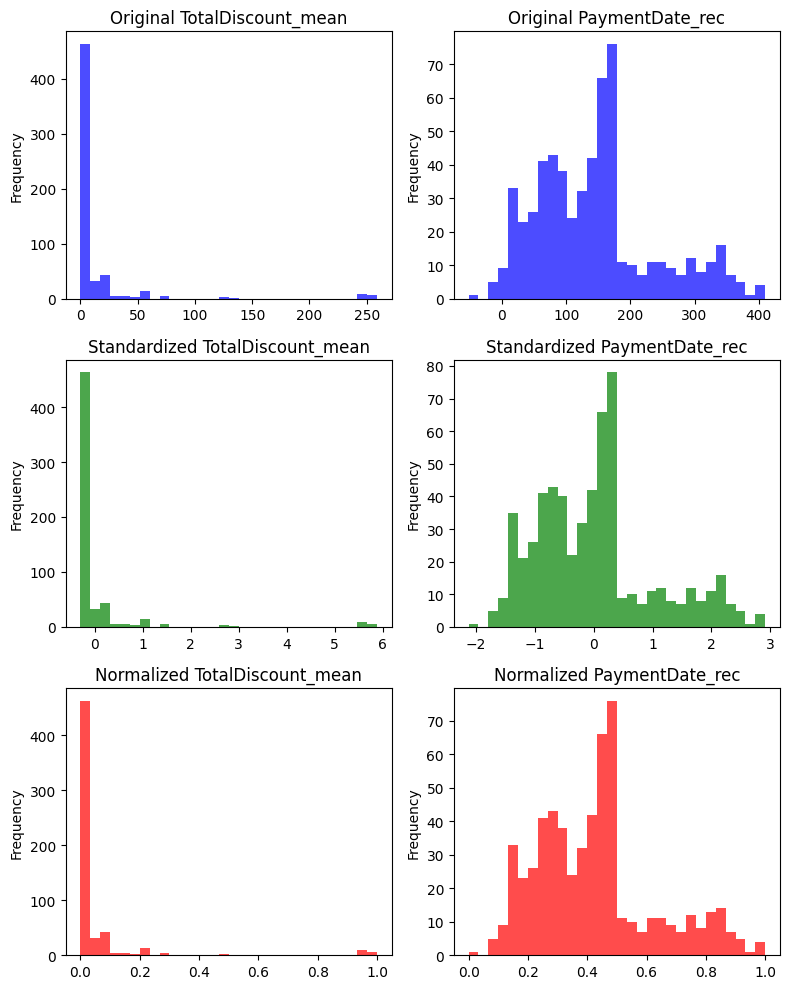

In [91]:
# Visualization comparison (demo features only)
fig, axes = plt.subplots(3, len(X_demo.columns), figsize=(4*len(X_demo.columns), 10))
if len(X_demo.columns) == 1:
    axes = axes.reshape(-1, 1)

for i, feature in enumerate(X_demo.columns):
    # Original
    axes[0,i].hist(X_demo[feature], bins=30, alpha=0.7, color='blue')
    axes[0,i].set_title(f'Original {feature}')
    axes[0,i].set_ylabel('Frequency')

    # Standardized
    axes[1,i].hist(X_standardized_df[feature], bins=30, alpha=0.7, color='green')
    axes[1,i].set_title(f'Standardized {feature}')
    axes[1,i].set_ylabel('Frequency')

    # Normalized
    axes[2,i].hist(X_normalized_df[feature], bins=30, alpha=0.7, color='red')
    axes[2,i].set_title(f'Normalized {feature}')
    axes[2,i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Important: Fit on training, transform on Test

As always a **critical rule** is to fit scalers on training data only, then transform both training and test sets using the training parameters.

**Note**: there was one crucial **mistake** in the previous scaling: **categorical variables should not be scaled**! At this point, everything is numerical in our dataset and we simply applied scaling to all variables. However, there are several dummy variables (e.g., the dummy variables) which should be seen as categorical. Hence, we should make sure that in our final transformation these variables are filtered out when scaling.  

In [92]:
# Seperate binary variables (variables with only 0 and 1 values)
binary_features = []
continuous_features = []

for col in train_final.columns:
    unique_values = train_final[col].unique()
    # Check if variable has only 2 unique values and they are 0 and 1
    # BUT exclude Pattern_0000100_sum as it's actually numeric despite having only 2 unique values
    if len(unique_values) == 2 and set(unique_values) == {0, 1} and col != 'Pattern_0000100_sum':
        binary_features.append(col)
    else:
        continuous_features.append(col)

print(f"\nFeature Analysis:")
print(f"Binary features (0/1 only): {len(binary_features)}")
print(f"Continuous features: {len(continuous_features)}")
print(f"\nBinary features (will NOT be scaled): {binary_features[:10]}")
if len(binary_features) > 10:
    print(f"... and {len(binary_features)-10} more")

# Note: Pattern_0000100_sum is treated as continuous despite having only 2 unique values

# Separate binary and continuous features
train_binary = train_final[binary_features]
train_continuous = train_final[continuous_features]
test_binary = test_final[binary_features]
test_continuous = test_final[continuous_features]


Feature Analysis:
Binary features (0/1 only): 10
Continuous features: 35

Binary features (will NOT be scaled): ['RenewalDate_rec_missing', 'PaymentDate_rec_missing', 'Gender_missing', 'Gender_M', 'District_2.0', 'District_5.0', 'District_6.0', 'District_7.0', 'District_8.0', 'District_9.0']


In [93]:
# Apply scaling ONLY to continuous features
scaler = StandardScaler()

# Fit on training continuous data only
scaler.fit(train_continuous)

# Transform continuous features only
train_continuous_scaled = scaler.transform(train_continuous)
test_continuous_scaled = scaler.transform(test_continuous)

# Step 3: Combine scaled continuous features with unscaled binary features
# Convert scaled arrays back to DataFrames
train_continuous_scaled_df = pd.DataFrame(train_continuous_scaled, columns=continuous_features, index=train_final.index)
test_continuous_scaled_df = pd.DataFrame(test_continuous_scaled, columns=continuous_features, index=test_final.index)

# Combine: scaled continuous + unscaled binary (in original column order)
train_final_scaled_df = pd.DataFrame(index=train_final.index)
test_final_scaled_df = pd.DataFrame(index=test_final.index)

for col in train_final.columns:
    if col in binary_features:
        train_final_scaled_df[col] = train_binary[col]
        test_final_scaled_df[col] = test_binary[col]
    else:
        train_final_scaled_df[col] = train_continuous_scaled_df[col]
        test_final_scaled_df[col] = test_continuous_scaled_df[col]

# Create numpy arrays for compatibility
train_final_scaled = train_final_scaled_df.values
test_final_scaled = test_final_scaled_df.values

print(f"\n Scaling Results:")
print(f" Continuous features scaled: {len(continuous_features)}")
print(f"Binary features kept original: {len(binary_features)}")
print(f"Final scaled training shape: {train_final_scaled_df.shape}")
print(f"Final scaled test shape: {test_final_scaled_df.shape}")



 Scaling Results:
 Continuous features scaled: 35
Binary features kept original: 10
Final scaled training shape: (589, 45)
Final scaled test shape: (589, 45)


### Summary: Transformations and scaling

**Transformation Guidelines:**

| Transformation | When to Use | Algorithm Examples |
|---|---|---|
| **Standardization** | Distance-based algorithms, comparing coefficients | SVM, KNN, Linear Regression |
| **Min-Max Normalization** | Neural networks, bounded features needed | Neural Networks, some clustering |
| **Polynomial Features** | Non-linear relationships in linear models | Linear/Logistic Regression |
| **Power Transforms** | Skewed data, improving normality | Linear models, parametric tests |
| **No Scaling** | Tree-based algorithms | Random Forest, XGBoost, Decision Trees |

### Feature Selection using Filter Methods

Feature selection is not always necessary at this point, but it can speed up analysis and make models more operational. We'll use `sklearn`'s filter methods to select the most informative features.

**Note:** We will use scale the data for feature selection since then all features are impacted equally.


### Filter Methods for Numerical Features

For continuous variables with categorical response, we'll use `sklearn`'s Fisher score equivalent (`f_classif`) and `SelectKBest`.  

In [94]:
# Feature selection using sklearn filter methods
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 20 features using f_classif (similar to Fisher score)
k_best_numerical = min(20, len(continuous_features))
selector_numerical = SelectKBest(score_func=f_classif, k=k_best_numerical)

# Fit the selector and get scores
X_numerical_selected = selector_numerical.fit_transform(train_continuous_scaled_df, y_train)

# Get feature scores and names
feature_scores = selector_numerical.scores_
selected_mask = selector_numerical.get_support()
selected_numerical_features = np.array(continuous_features)[selected_mask].tolist()

# Create results dataframe
numerical_results = pd.DataFrame({
    'feature': continuous_features,
    'f_score': feature_scores,
    'selected': selected_mask
}).sort_values('f_score', ascending=False)

print(f"Top 10 continuous numerical features by F-score:")
print(numerical_results.head(10)[['feature', 'f_score', 'selected']])

print(f"\nSelected continuous numerical features ({len(selected_numerical_features)}):")
print(selected_numerical_features)


Top 10 continuous numerical features by F-score:
                   feature     f_score  selected
20           StartDate_rec  105.595305      True
22         PaymentDate_rec   93.995147      True
29    FormulaDiscount_mean   71.133723      True
27  NetNewspaperPrice_mean   52.653478      True
24           NbrStart_mean   34.391696      True
31         TotalPrice_mean   33.057998      True
18  PaymentStatus_Paid_sum   31.056359      True
15     Pattern_1111110_sum   28.830724      True
16      PaymentType_BT_sum   24.807797      True
26    NetFormulaPrice_mean   22.855152      True

Selected continuous numerical features (20):
['ProductID_4_sum', 'ProductID_6_sum', 'ProductID_8_sum', 'Pattern_1111110_sum', 'PaymentType_BT_sum', 'PaymentType_DD_sum', 'PaymentStatus_Paid_sum', 'PaymentStatus_Not.Paid_sum', 'StartDate_rec', 'RenewalDate_rec', 'PaymentDate_rec', 'NbrNewspapers_mean', 'NbrStart_mean', 'GrossFormulaPrice_mean', 'NetFormulaPrice_mean', 'NetNewspaperPrice_mean', 'FormulaDiscoun

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [12 14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


#### Filter Methods for Categorical Features

For categorical variables, we'll use mutual information which is similar to Information Value (IV) concept and Chi-square analysis. Note that we already have a `train_binary` dataset, so let's use this one.

In [96]:
# Categorical Feature Selection (Binary features only)
from sklearn.feature_selection import mutual_info_classif, chi2

# Binary features for categorical analysis (chi2/mutual info)
print(f"Binary features for categorical analysis: {len(binary_features)}")

# Apply chi-squared feature selection
k_best_categorical = min(5, len(binary_features))
selector_categorical_chi2 = SelectKBest(score_func=chi2, k=k_best_categorical)
X_categorical_selected = selector_categorical_chi2.fit_transform(train_binary, y_train)

# Get selected feature names and scores
selected_mask_chi2 = selector_categorical_chi2.get_support()
selected_categorical_features_chi2 = [f for f, selected in zip(binary_features, selected_mask_chi2) if selected]
chi2_scores = selector_categorical_chi2.scores_

# Create results dataframe for chi-squared
categorical_results_chi2 = pd.DataFrame({
    'Feature': binary_features,
    'Chi2_Score': chi2_scores,
    'Selected': selected_mask_chi2
}).sort_values('Chi2_Score', ascending=False)

# Print selected categorical features by Chi-squared
print(f"\nSelected categorical binary features by Chi-squared ({len(selected_categorical_features_chi2)}):")
print(selected_categorical_features_chi2)
print(f"Top binary features by Chi-squared:")
print(categorical_results_chi2.head())

Binary features for categorical analysis: 10

Selected categorical binary features by Chi-squared (5):
['RenewalDate_rec_missing', 'PaymentDate_rec_missing', 'Gender_missing', 'District_7.0', 'District_9.0']
Top binary features by Chi-squared:
                   Feature  Chi2_Score  Selected
0  RenewalDate_rec_missing  107.130914      True
2           Gender_missing    9.107489      True
1  PaymentDate_rec_missing    5.455696      True
7             District_7.0    3.249496      True
6             District_6.0    2.727848     False


In [97]:
# Apply Mutual Information for binary features
selector_categorical_mi = SelectKBest(score_func=mutual_info_classif, k=k_best_categorical)
X_categorical_selected_mi = selector_categorical_mi.fit_transform(train_binary, y_train)

# Get selected feature names and scores
selected_mask_mi = selector_categorical_mi.get_support()
selected_categorical_features_mi = [f for f, selected in zip(binary_features, selected_mask_mi) if selected]
mi_scores = selector_categorical_mi.scores_

# Create results dataframe for mutual information
categorical_results_mi = pd.DataFrame({
    'Feature': binary_features,
    'MI_Score': mi_scores,
    'Selected': selected_mask_mi
}).sort_values('MI_Score', ascending=False)

# Print results
print(f"\nSelected binary categorical features by Chi-squared ({len(selected_categorical_features_mi)}):")
print(selected_categorical_features_mi)
print(f"\nTop binary features by Mutual Information:")
print(categorical_results_mi.head())


Selected binary categorical features by Chi-squared (5):
['RenewalDate_rec_missing', 'Gender_missing', 'Gender_M', 'District_5.0', 'District_8.0']

Top binary features by Mutual Information:
                   Feature  MI_Score  Selected
0  RenewalDate_rec_missing  0.079577      True
8             District_8.0  0.059595      True
2           Gender_missing  0.017793      True
5             District_5.0  0.007230      True
3                 Gender_M  0.006457      True


Finally, we can combine the results of the numerical and categorical feature selection to create the final dataset. For the categorical ones, we will take the intersect of both methods.

In [98]:
# Combine all selected features
all_selected_features = list(set(selected_numerical_features + list(set(selected_categorical_features_chi2) & set(selected_categorical_features_mi))))

print(f"\nTotal selected features: {len(all_selected_features)}")
print(f"From continuous: {len(selected_numerical_features)}")
print(f"From binary: {len(set(selected_categorical_features_chi2) & set( selected_categorical_features_mi))}") #intersection of the two

# Create final filtered dataset
train_final_selected_scaled = train_final_scaled_df[all_selected_features]
print(f"Filtered dataset shape: {train_final_selected_scaled.shape}")

# Select the same features from the test set
test_final_selected_scaled = test_final_scaled_df[all_selected_features]
print(f"Filtered test dataset shape: {test_final_selected_scaled.shape}")



Total selected features: 22
From continuous: 20
From binary: 2
Filtered dataset shape: (589, 22)
Filtered test dataset shape: (589, 22)


### Summary: Feature selection

**Key Achievement**: We went from 45 variables to 23 variables, which make our models more compact and operational.

**Feature Selection Improvements:**
- **Continuous features**: Use scaled data with Fisher score for numerical variables
- **Binary features**: Treated as categorical, analyzed with chi2/mutual_info
- **Best practice**: Different variable types handled with appropriate methods

**Note**: Determining the best filter methods and the true optimal number of features should be done at a later stage using cross-validation, to evaluate how feature selection impacts model performance.

### Ordinal encoding

Ordinal variables have a natural order in their categories. Unlike nominal categorical variables, the order matters in ordinal variables. Since there is no ordinal variable in our dataset, we will demonstrate different approaches to encoding ordinal variables using a realistic synthetic **customer value tier**.

This customer value tier will be determined based on:
1.	Total product purchases
    - Computed as the sum of all `ProductID`-related features.
    - Higher values imply more frequent or diverse purchasing behavior.
2.	Payment recency
    - Derived from `PaymentDate_rec`, which measures how long it has been since the last payment.
    - A smaller value indicates recent activity, which is typically a strong signal of engagement.


In [100]:
# Create Customer Value Tier based on actual dataset features

# Set random seed for reproducibility
np.random.seed(42)

# We'll analyze the actual dataset to create meaningful customer segments
print("Dataset analysis for Customer Value Tier creation:")
print(f"Training data shape: {train_final.shape}")

# Let's examine some key features for customer segmentation
# Focus on payment patterns, product usage, and discount behavior
key_features = []

# Check for product and payment related features
for col in train_final.columns:
    if 'ProductID' in col and '_sum' in col:
        key_features.append(col)
    elif 'PaymentDate' in col and col != 'PaymentDate_rec_missing':
        key_features.append(col)

print(f"Key features for segmentation: {key_features[:10]}...")  # Show first 10

# Create customer value score based on:
# 1. Total product purchases (sum of ProductID features)
# 2. Payment recency (PaymentDate_rec)

# Calculate total product purchases per customer
product_cols = [col for col in train_final.columns if 'ProductID' in col and '_sum' in col]
total_products = train_final[product_cols].sum(axis=1)

# Get payment recency (higher = less recent, i.e., more days since last payment)
payment_recency = train_final['PaymentDate_rec'] if 'PaymentDate_rec' in train_final.columns else np.random.uniform(0, 365, len(train_final))

# Create customer value tiers based on quartiles of combined score
# Higher product usage + lower payment recency (more recent) = higher value
recency_factor = 1 / (1 + payment_recency)
value_score = (total_products * 0.7 + recency_factor * 0.3)

# Create ordinal tiers based on quartiles
q1, q2, q3 = np.percentile(value_score, [25, 50, 75])

def assign_tier(score):
    if score <= q1:
        return 'Bronze'
    elif score <= q2:
        return 'Silver'
    elif score <= q3:
        return 'Gold'
    else:
        return 'Platinum'

# Apply tier assignment
customer_tiers = [assign_tier(score) for score in value_score]

print("\nCustomer Value Tier Distribution:")
tier_counts = pd.Series(customer_tiers).value_counts()
print(tier_counts)



Dataset analysis for Customer Value Tier creation:
Training data shape: (589, 45)
Key features for segmentation: ['ProductID_1_sum', 'ProductID_2_sum', 'ProductID_3_sum', 'ProductID_4_sum', 'ProductID_5_sum', 'ProductID_6_sum', 'ProductID_7_sum', 'ProductID_8_sum', 'PaymentDate_rec']...

Customer Value Tier Distribution:
Silver      153
Bronze      148
Platinum    147
Gold        141
Name: count, dtype: int64


In [101]:
# Define churn probabilities by tier (higher tier = lower churn)
tier_churn_probs = {'Bronze': 0.6, 'Silver': 0.4, 'Gold': 0.25, 'Platinum': 0.15}

# Create synthetic churn based on value tiers
synthetic_churn = [np.random.binomial(1, tier_churn_probs[tier]) for tier in customer_tiers]

# Create training data for ordinal encoding
X_train_ordinal = pd.DataFrame({'customer_tier': customer_tiers})
y_train = pd.Series(synthetic_churn, name='churn')

print("\nChurn rate by Customer Value Tier:")
tier_churn_analysis = pd.DataFrame({
    'customer_tier': customer_tiers,
    'churn': synthetic_churn
}).groupby('customer_tier')['churn'].agg(['mean', 'count']).round(3)
print(tier_churn_analysis)

# Create test data with similar distribution
test_size = 200
test_value_scores = np.random.uniform(value_score.min(), value_score.max(), test_size)
test_tiers = [assign_tier(score) for score in test_value_scores]
test_churn = [np.random.binomial(1, tier_churn_probs[tier]) for tier in test_tiers]

X_test_ordinal = pd.DataFrame({'customer_tier': test_tiers})
y_test = pd.Series(test_churn, name='churn')

print(f"\nTraining set shape: {X_train_ordinal.shape}")
print(f"Test set shape: {X_test_ordinal.shape}")
print(f"Total products range: {total_products.min():.1f} - {total_products.max():.1f}")
print(f"Value score range: {value_score.min():.1f} - {value_score.max():.1f}")


Churn rate by Customer Value Tier:
                mean  count
customer_tier              
Bronze         0.554    148
Gold           0.291    141
Platinum       0.129    147
Silver         0.399    153

Training set shape: (589, 1)
Test set shape: (200, 1)
Total products range: 1.0 - 30.0
Value score range: 0.4 - 21.0


#### Manual Ordinal Encoding (sklearn)

In normal ordinal encoding, we specify the order of categories based on domain knowledge. For customer tiers, the natural order is Bronze < Silver < Gold < Platinum.

In [102]:
# Method 1: Manual Ordinal Encoding with sklearn OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

# Define the order based on customer value (lowest to highest)
tier_order = [['Bronze', 'Silver', 'Gold', 'Platinum']]

# Create sklearn ordinal encoder with specified order
sklearn_encoder = OrdinalEncoder(categories=tier_order)

# Fit and transform the training data
X_train_sklearn_encoded = sklearn_encoder.fit_transform(X_train_ordinal)

# Apply to test data
X_test_sklearn_encoded = sklearn_encoder.transform(X_test_ordinal)

print("Manual Ordinal Encoding with sklearn")
print("Domain-knowledge based encoding:")
print("Bronze → 0, Silver → 1, Gold → 2, Platinum → 3")

# Show examples of encoding
comparison_normal = pd.DataFrame({
    'Original': X_train_ordinal['customer_tier'].unique(),
    'Encoded': [sklearn_encoder.categories_[0].tolist().index(tier) for tier in X_train_ordinal['customer_tier'].unique()]
})
print(comparison_normal.sort_values('Encoded'))

Manual Ordinal Encoding with sklearn
Domain-knowledge based encoding:
Bronze → 0, Silver → 1, Gold → 2, Platinum → 3
   Original  Encoded
0    Bronze        0
2    Silver        1
1      Gold        2
3  Platinum        3


#### Automated ordinal encoding (Feature Engine)

Feature Engine's `OrdinalEncoder` automatically orders categories by their relationship with the target variable, assigning lower values to categories with lower target means.

In [103]:
# Method 2: Feature Engine's OrdinalEncoder (orders by target mean)
from feature_engine.encoding import OrdinalEncoder

# Create Feature Engine ordinal encoder
fe_encoder = OrdinalEncoder(variables=['customer_tier'])

# Fit and transform the training data
X_train_fe_encoded = fe_encoder.fit_transform(X_train_ordinal, y_train)

# Apply to test data
X_test_fe_encoded = fe_encoder.transform(X_test_ordinal)

# Display the encoding mapping
print("Feature Engine Ordinal Encoding Mapping:")
print(f"Categories ordered by churn rate (ascending): {fe_encoder.encoder_dict_['customer_tier']}")

# Compare encodings
comparison_fe = pd.DataFrame({
    'customer_tier': X_train_ordinal['customer_tier'].unique(),
    'sklearn_encoding': [sklearn_encoder.categories_[0].tolist().index(tier) for tier in X_train_ordinal['customer_tier'].unique()],
    'feature_engine_encoding': [fe_encoder.encoder_dict_['customer_tier'][tier] for tier in X_train_ordinal['customer_tier'].unique()]
})
print("\nComparison of encoding methods:")
print(comparison_fe.sort_values('customer_tier'))

Feature Engine Ordinal Encoding Mapping:
Categories ordered by churn rate (ascending): {'Platinum': 0, 'Gold': 1, 'Silver': 2, 'Bronze': 3}

Comparison of encoding methods:
  customer_tier  sklearn_encoding  feature_engine_encoding
0        Bronze                 0                        3
1          Gold                 2                        1
3      Platinum                 3                        0
2        Silver                 1                        2


#### Target Encoding (ean Encoding)

Target encoding replaces each category with the mean of the target variable for that category. This creates a direct relationship between the encoded value and the target.

In [104]:
# Method 3: Target Encoding (Mean Encoding)
from feature_engine.encoding import MeanEncoder

# Create target encoder
target_encoder = MeanEncoder(variables=['customer_tier'])

# Fit and transform the training data
X_train_target_encoded = target_encoder.fit_transform(X_train_ordinal, y_train)

# Apply to test data
X_test_target_encoded = target_encoder.transform(X_test_ordinal)

# Display the encoding mapping
print("Target Encoding Mapping (Mean churn rate for each tier):")
print(f"Encoding dictionary: {target_encoder.encoder_dict_['customer_tier']}")

# Create comprehensive comparison using our target variable y_train
temp_df = pd.DataFrame({'customer_tier': X_train_ordinal['customer_tier'], 'churn': y_train})
target_means = temp_df.groupby('customer_tier')['churn'].mean()

comparison_all = pd.DataFrame({
    'customer_tier': X_train_ordinal['customer_tier'].unique(),
    'churn_rate': [target_means[tier] for tier in X_train_ordinal['customer_tier'].unique()],
    'sklearn_ordinal': [sklearn_encoder.categories_[0].tolist().index(tier) for tier in X_train_ordinal['customer_tier'].unique()],
    'feature_engine_ordinal': [fe_encoder.encoder_dict_['customer_tier'][tier] for tier in X_train_ordinal['customer_tier'].unique()],
    'target_encoding': [target_encoder.encoder_dict_['customer_tier'][tier] for tier in X_train_ordinal['customer_tier'].unique()]
})

print("\nComplete comparison of all encoding methods:")
print(comparison_all.sort_values('churn_rate'))

Target Encoding Mapping (Mean churn rate for each tier):
Encoding dictionary: {'Bronze': 0.5540540540540541, 'Gold': 0.2907801418439716, 'Platinum': 0.1292517006802721, 'Silver': 0.39869281045751637}

Complete comparison of all encoding methods:
  customer_tier  churn_rate  sklearn_ordinal  feature_engine_ordinal  \
3      Platinum    0.129252                3                       0   
1          Gold    0.290780                2                       1   
2        Silver    0.398693                1                       2   
0        Bronze    0.554054                0                       3   

   target_encoding  
3         0.129252  
1         0.290780  
2         0.398693  
0         0.554054  


#### Summary: Ordinal encoding

**When to use each method:**

1. **Manual Ordinal Encoding (sklearn)**: When you have clear business hierarchy or domain knowledge
   - Example: Customer tiers, education levels, product ratings
   - Maintains business logic and interpretability

2. **Automated Ordinal Encoding (feature-engine)**: When you want data-driven ordering
   - Automatically finds optimal order based on target relationship (always in ascending order!)
   - Useful for discovering hidden patterns in categorical variables
   - If you set `ignore_format=False`, you can also specify the order yourself

3. **Target Encoding**: When you want direct predictive power
   - Creates strongest statistical relationship with target
   - Risk of overfitting, especially with small sample sizes

**Important considerations:**
- Manual encoding preserves business meaning but may not be optimal for prediction
- Automated encoding can reveal surprising patterns but may be less interpretable (e.g., why would platinum be coded as 0?)
- Target encoding maximizes predictive power but requires careful cross-validation and other methods like WoE can be better.